# Unit 3

In [3]:
# Define path for files
path = r"C:\Users\cramb\OneDrive\Desktop\Bootcamp26\Images\\"

## Probability
### Discrete Random Variables

In [5]:
# Import modules
import numpy as np
from scipy.stats import binom

# Generate 100,000 simulations
defaults = binom.rvs(n = 25, p = 0.05, loc = 0, size = 100_000, random_state = 0)

# Calculate probability
prob = np.mean(defaults > 1)

print(f'The probability that more than one bond defaults is {prob:.3f}.')

The probability that more than one bond defaults is 0.357.


### Continuous Random Variables

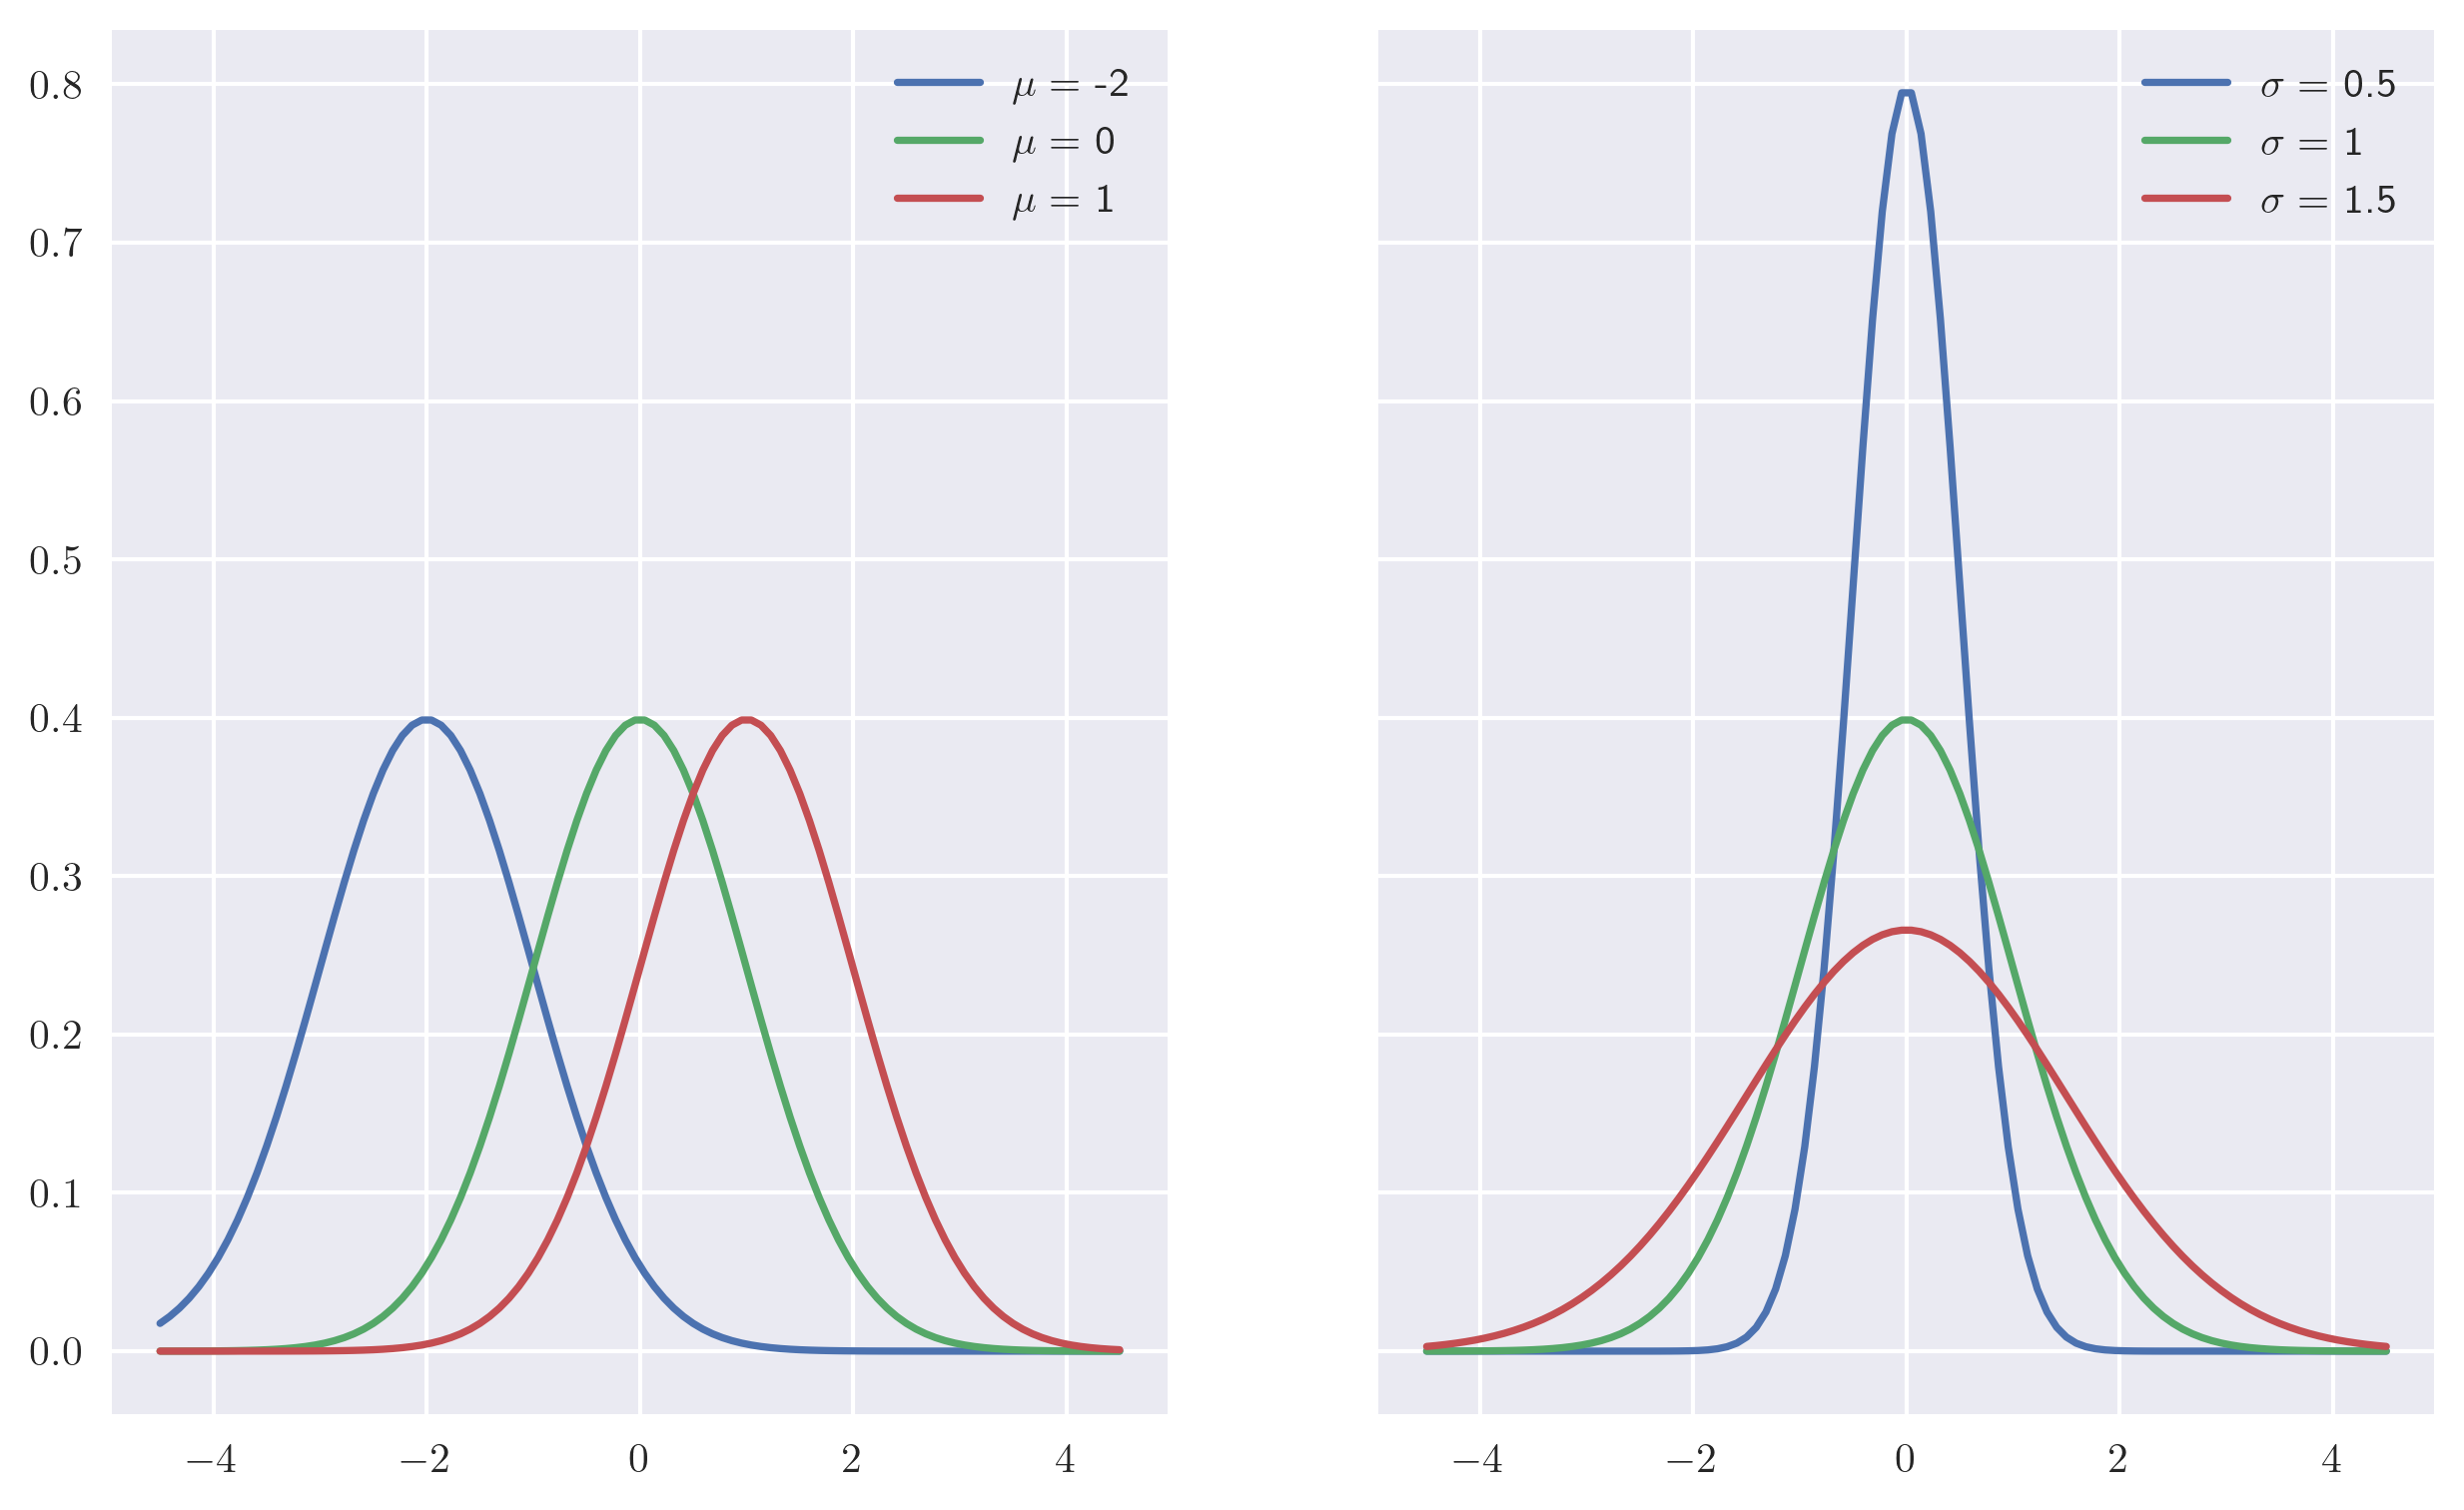

In [3]:
# Import modules
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import norm

# Use LaTeX and increase resolution
plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 300

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Mu- and sigma-values
mu_vals, sigma_vals = [-2, 0, 1], [0.5, 1, 1.5]

# Set up subplots
fig, ax = plt.subplots(1, 2, sharey = True, figsize = (10, 6))

# Get x-values
x_vals = np.linspace(-4.5, 4.5, 100)

# Loop over mu-values
for mu in mu_vals:

    # Note norm.pdf vectorized
    y_vals = norm.pdf(x_vals, loc = mu, scale = 1)
    
    ax[0].plot(x_vals, y_vals, label = fr'$\mu =$ {mu}')

# Loop over sigma-values
for sigma in sigma_vals:
    
    # Note norm.pdf vectorized; also scale is std not var
    y_vals = norm.pdf(x_vals, loc = 0, scale = sigma)
    
    ax[1].plot(x_vals, y_vals, label = fr'$\sigma =$ {sigma}')

# Create legend for subplots
ax[0].legend()
ax[1].legend()

# Save the figure
plt.savefig(path + r'ex3-1.png')

# Show plot
plt.show()

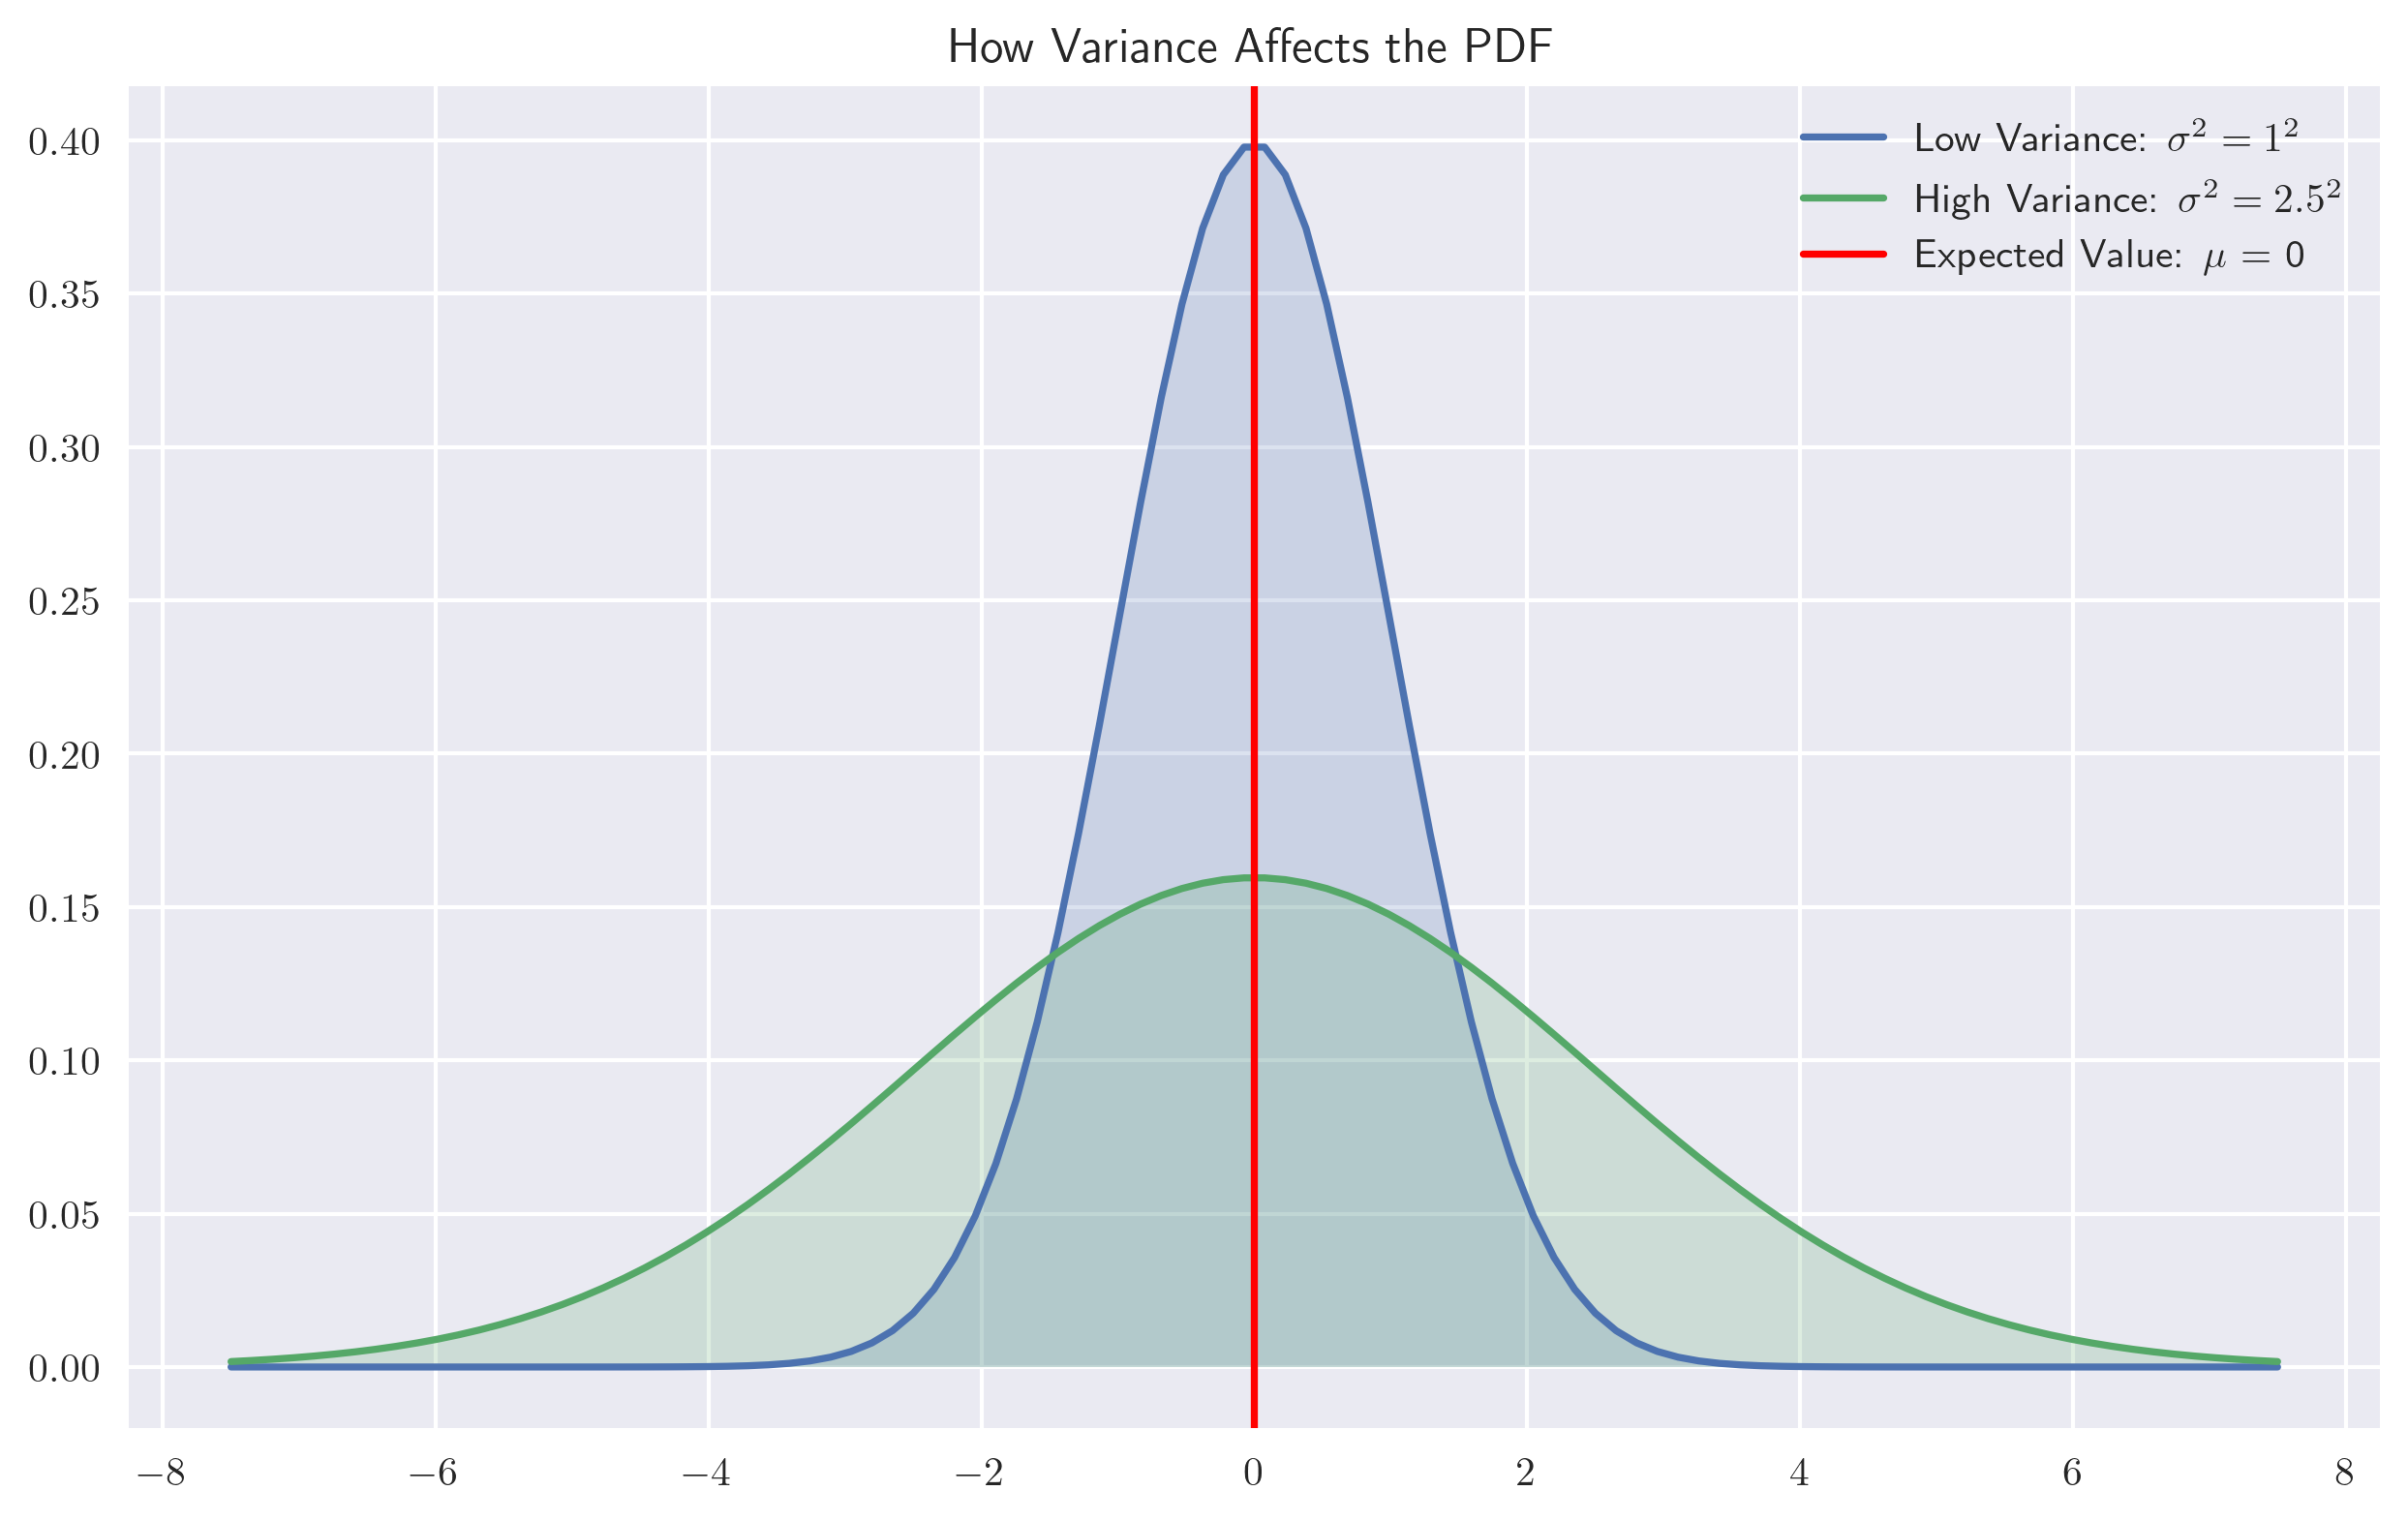

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Use LaTeX and increase resolution
plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 300

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Say that expected value is 0
mu = 0

# Define high and how standard deviations
sigma_low, sigma_high = 1, 2.5   

# Create a range of x-values for the plot
x = np.linspace(-7.5, 7.5, 100)

# Calculate the pdf values
y_low_var = norm.pdf(x, mu, sigma_low)
y_high_var = norm.pdf(x, mu, sigma_high)

# Set the figure size
plt.figure(figsize = (10, 6))

plt.plot(x, y_low_var, label=  rf'Low Variance: $\sigma^2 = {sigma_low}^2$')
plt.fill_between(x, y_low_var, alpha = 0.2)

plt.plot(x, y_high_var, label = rf'High Variance: $\sigma^2 = {sigma_high}^2$')
plt.fill_between(x, y_high_var, alpha = 0.2)

# Create vertical line at expected value
plt.axvline(mu, color = 'red', label = rf'Expected Value: $\mu$ = {mu}')

# Add a title
plt.title('How Variance Affects the PDF')

# Add a legend
plt.legend(loc = 'upper right')

# Save the figure
plt.savefig(path + r'variance.png')

plt.show()

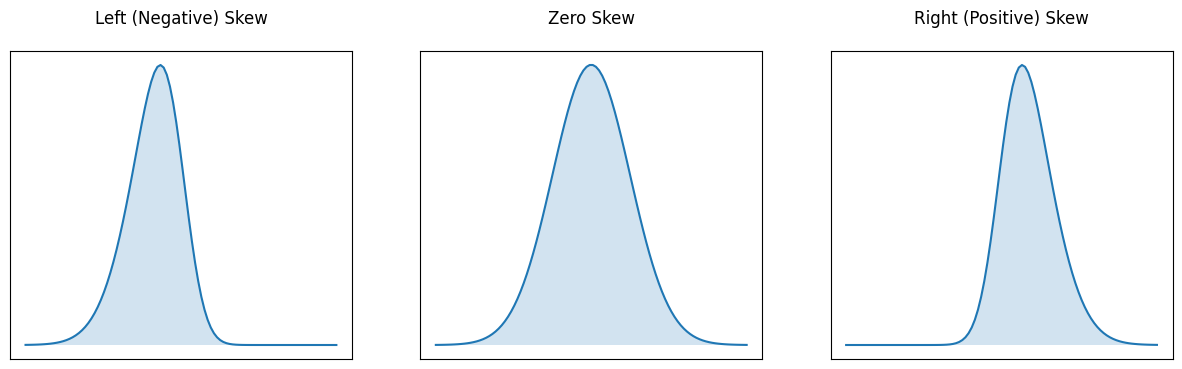

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skewnorm

# Use LaTeX and increase resolution
plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 300

# Use Seaborn style
plt.style.use('default')

# What skews will we use?
skews = [-2, 0, 2]  

# Corresponding labels
skew_titels = ['Left (Negative) Skew', 'Zero Skew', 'Right (Positive) Skew']

# Define x-values
x = np.linspace(-4, 4, 100)

fig, ax = plt.subplots(1, 3, figsize = (15, 4))

for i, a_val in enumerate(skews):
    
    # Calculate the Skew-Normal PDF
    y = skewnorm.pdf(x, a_val)
    
    # Plot the curve and the shaded area underneath
    ax[i].plot(x, y)
    ax[i].fill_between(x, y, alpha = 0.2)
    
    # Add title
    ax[i].set_title(skew_titels[i], pad = 20)

    # Remove numerical ticks 
    ax[i].set_xticks([])
    ax[i].set_yticks([])

# Save the figure
plt.savefig(path + r'skew.png')

plt.show()


### Moments

In [7]:
# Import modules
import yfinance as yf
import datetime

# Define start and end dates
start = datetime.datetime(2020, 1, 1)
end = datetime.datetime(2026, 4, 30)

# Get two S&P 500 ETFs
spx_rtn = yf.download(['SPY', 'IVV'], start = start  - datetime.timedelta(weeks = 1), 
                      end = end, progress = False, auto_adjust = True)['Close']

# Calculate the percent change
spx_rtn = spx_rtn.pct_change().dropna()

# Take the average to minimize weird stuff
spx_rtn = spx_rtn.mean(axis = 1)

# Subset to just dates after start
spx_rtn = spx_rtn.loc[spx_rtn.index >= start]

# Convert to percent
spx_rtn *= 100

# Change name of series
spx_rtn.name = 'SPX'

# Save results to a csv file
spx_rtn.to_csv(path.replace('Images', 'Unit 3') + 'spx_rtn.csv')

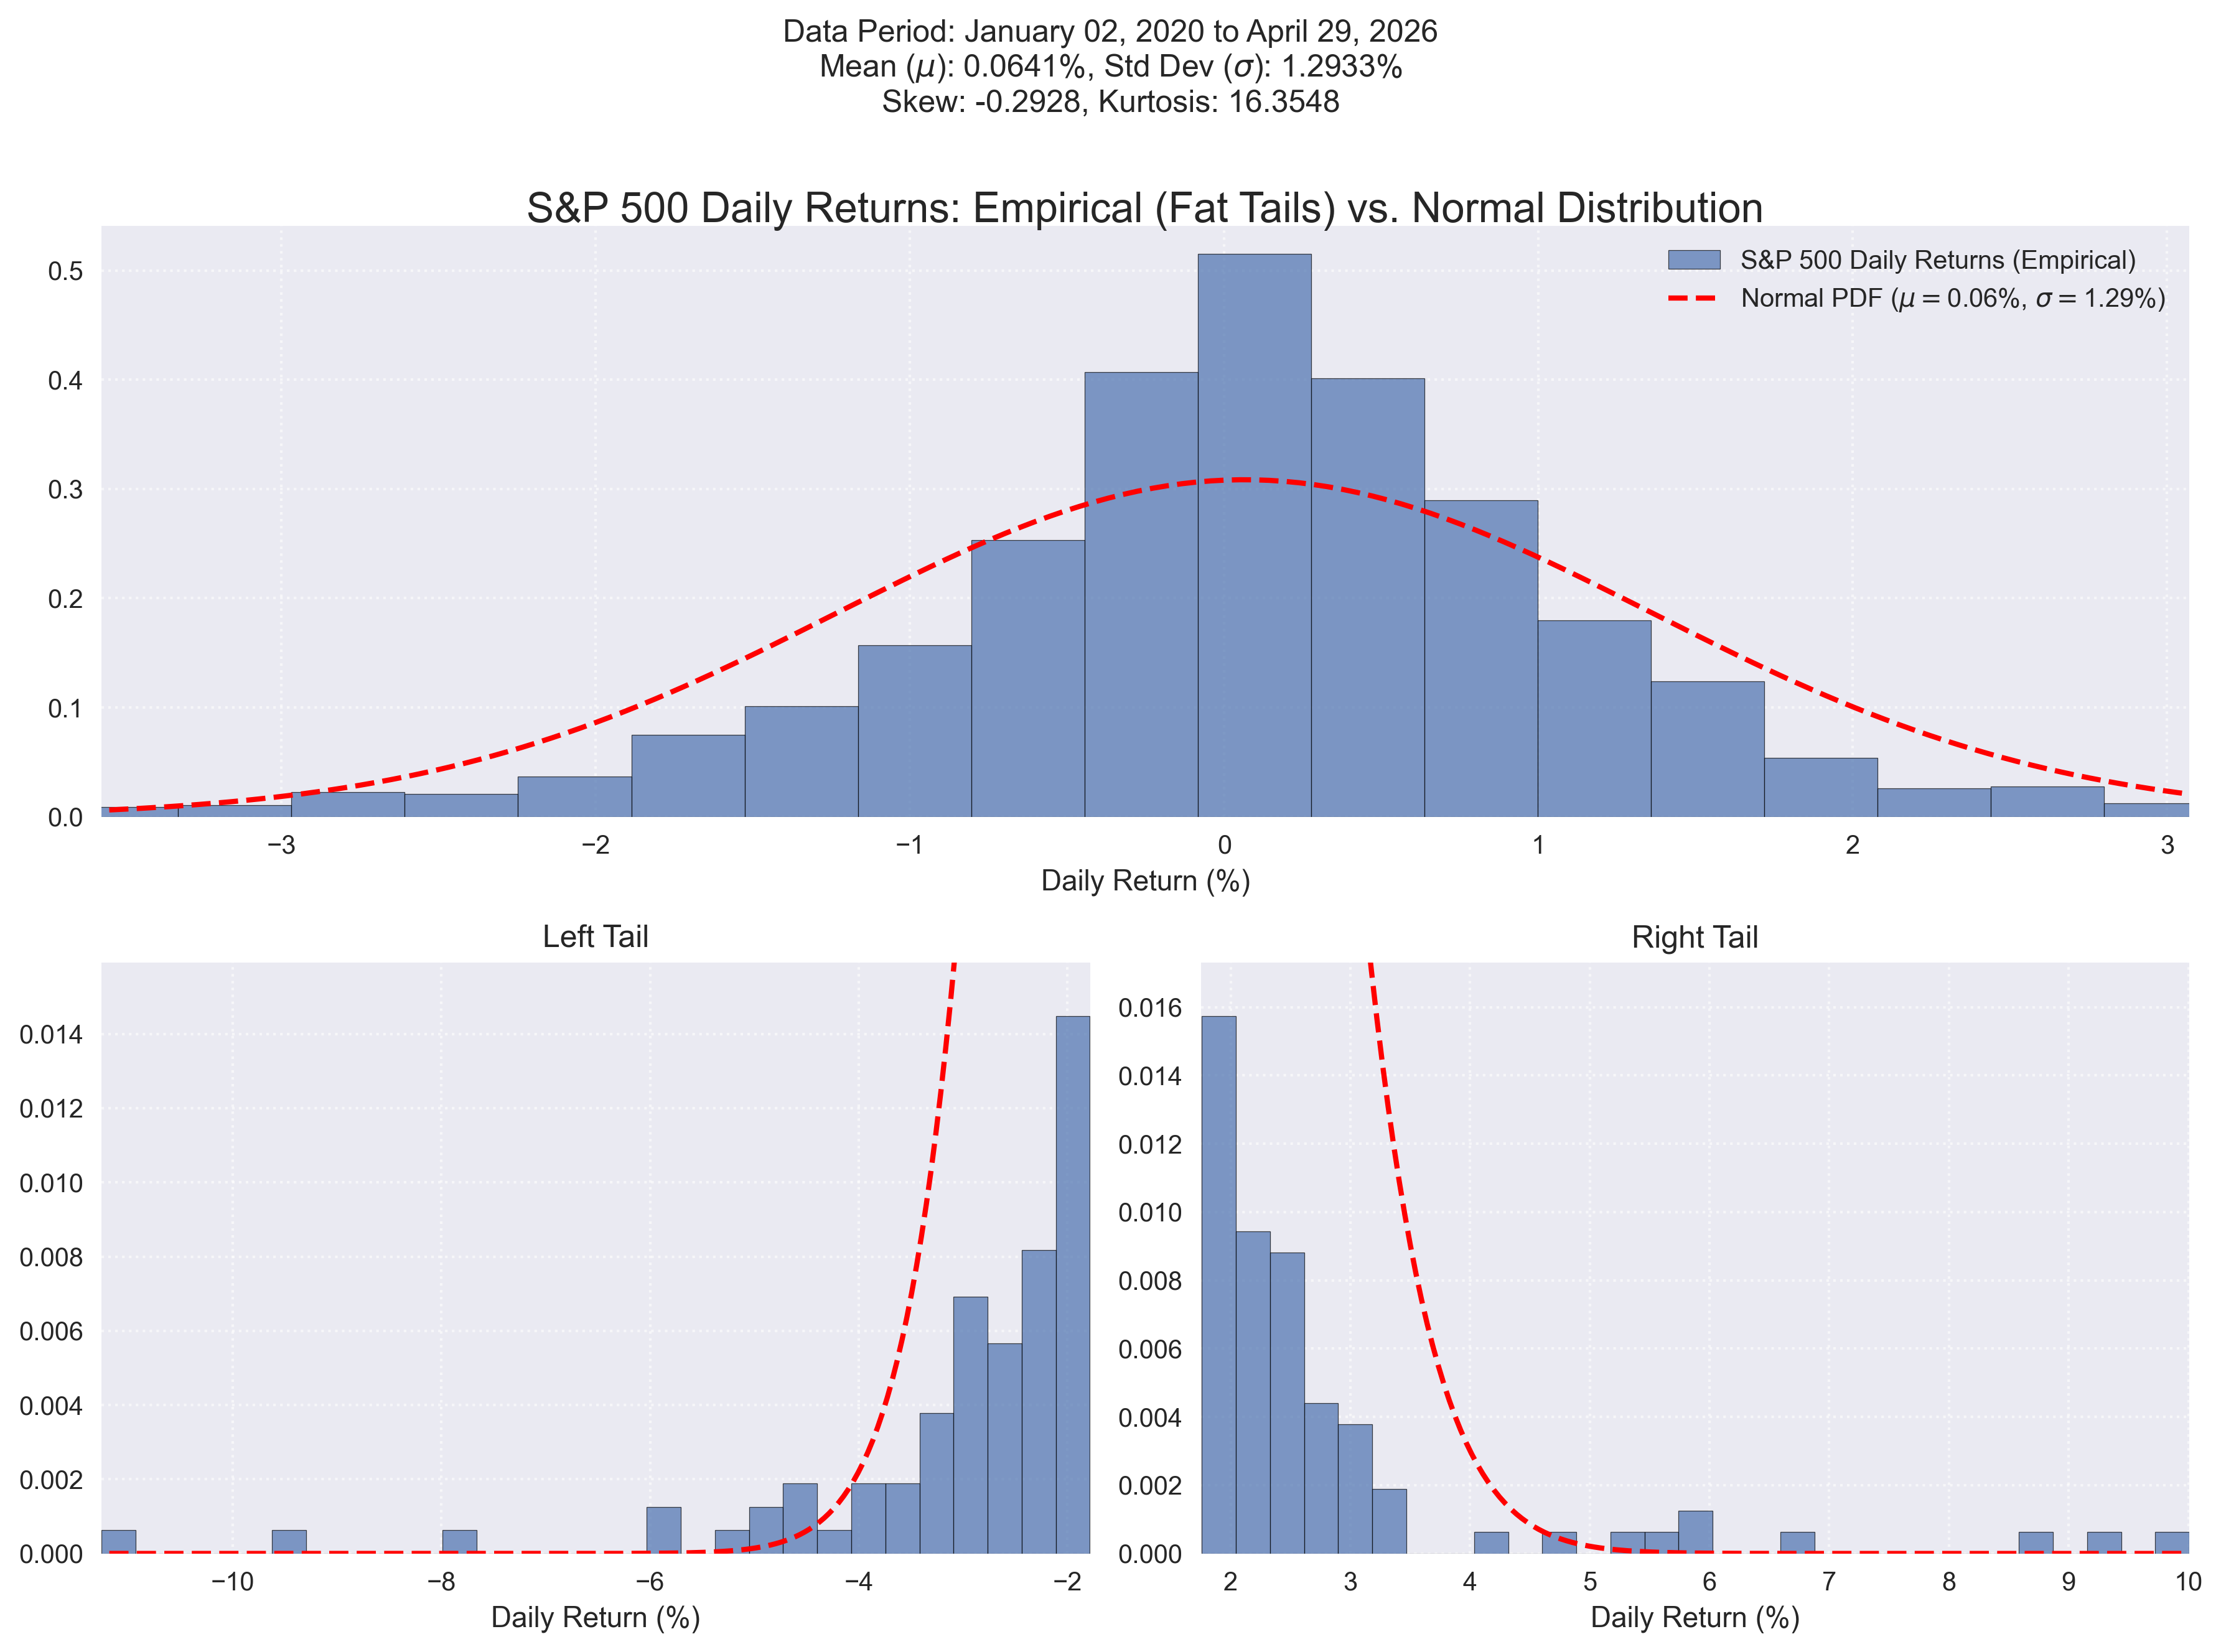

In [11]:
# Import modules
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm

# Calculate mean and standard deviation of the returns
mu_spx, sigma_spx = spx_rtn.mean(), spx_rtn.std()

# Get the number of observations
num_obs = spx_rtn.shape[0]

# Calculate bins for the histogram
num_bins = int(1.5 * np.sqrt(len(spx_rtn)))

# --- Plotting Setup ---

# Set these as usual
plt.rcParams['text.usetex'], plt.rcParams['figure.dpi'] = False, 300

# Use seaborn style
plt.style.use('seaborn-v0_8') 

# Overall figure size
fig = plt.figure(figsize = (12, 10)) 

# Define subplot grid using GridSpec for custom layout
gs = fig.add_gridspec(2, 2) 

# Top plot covers two columns
ax_full = fig.add_subplot(gs[0, :])

# Bottom-left plot is for the left tail
ax_left_tail = fig.add_subplot(gs[1, 0])

# Bottom-right plot is for the right tail
ax_right_tail = fig.add_subplot(gs[1, 1])

# --- Plotting the Main Histogram and Normal PDF ---

# Histogram of S&P 500 returns
ax_full.hist(spx_rtn, bins = num_bins, density = True, alpha = 0.7,
             label = 'S&P 500 Daily Returns (Empirical)', 
             edgecolor = 'black')

# Generate the x-values for the pdf plot
x = np.linspace(spx_rtn.min() - 1, spx_rtn.max() + 1, 500)

# Get the normal pdf values for comparison
pdf_values = norm.pdf(x, loc = mu_spx, scale = sigma_spx)

# Plot the pdf values
ax_full.plot(x, pdf_values, color = 'red', linestyle = '--', linewidth = 2,
             label = rf'Normal PDF ($\mu=${mu_spx:.2f}%, $\sigma=${sigma_spx:.2f}%)')

ax_full.set_title('Distribution of S&P 500 Daily Returns vs. Normal Distribution')
ax_full.set_xlabel('Daily Return (%)')
ax_full.set_xlim([spx_rtn.quantile(0.01), spx_rtn.quantile(0.99)])
ax_full.legend()
ax_full.grid(True, linestyle = ':', alpha = 0.6)

# --- Plotting the Tails ---

# Define tail thresholds 
left_tail_threshold = spx_rtn.quantile(0.05)
right_tail_threshold = spx_rtn.quantile(0.95)

# --- Left Tail Plot ---
# Filter data and pdf for the left tail
spx_left_tail = spx_rtn[spx_rtn < left_tail_threshold]
x_left_tail = x[x < 0.8 * left_tail_threshold]
pdf_left_tail = pdf_values[x < 0.8 * left_tail_threshold]

# Create weights for the height of the histogram
weights_left = np.ones_like(spx_left_tail)/num_obs

# Create histogram; save counts for height calculation later
counts, _, _ = ax_left_tail.hist(spx_left_tail, bins = num_bins//2, weights = weights_left, 
                                 alpha = 0.7, edgecolor = 'black')

# Plot the normal pdf on the left tail
ax_left_tail.plot(x_left_tail, pdf_left_tail, color = 'red', linestyle = '--', linewidth = 2)

ax_left_tail.set_title('Left Tail')
ax_left_tail.set_xlabel('Daily Return (%)')
ax_left_tail.grid(True, linestyle = ':', alpha = 0.6)

# Adjust x-limits to focus on the tail
ax_left_tail.set_xlim(spx_rtn.min(), left_tail_threshold)
ax_left_tail.set_ylim(0, 1.1 * np.max(counts))

# --- Right Tail Plot ---
# Filter data and PDF for the right tail
spx_right_tail = spx_rtn[spx_rtn > right_tail_threshold]
x_right_tail = x[x > 0.8 * right_tail_threshold]
pdf_right_tail = pdf_values[x > 0.8 * right_tail_threshold]

# Create weights for the height of the histogram
weights_right = np.ones_like(spx_right_tail)/num_obs

# Create histogram; save counts for height calculation later
counts, _, _ = ax_right_tail.hist(spx_right_tail, bins = num_bins//2, weights = weights_right, 
                                  alpha = 0.7, edgecolor = 'black')

# Plot the normal pdf on the right tail
ax_right_tail.plot(x_right_tail, pdf_right_tail, color = 'red', linestyle = '--', linewidth = 2)

ax_right_tail.set_title('Right Tail')
ax_right_tail.set_xlabel('Daily Return (%)')
ax_right_tail.grid(True, linestyle = ':', alpha = 0.6)

# Adjust x-limits to focus on the tail
ax_right_tail.set_xlim(right_tail_threshold, spx_rtn.max())
ax_right_tail.set_ylim(0, 1.1 * np.max(counts))

# --- Final Adjustments ---
# Add main title
ax_full.set_title(r'S&P 500 Daily Returns: Empirical (Fat Tails) vs. Normal Distribution',
             fontsize = 16, y = 0.98) 

# Add some stats to the top
fig.suptitle(f'Data Period: {spx_rtn.index.min().strftime("%B %d, %Y")} to {spx_rtn.index.max().strftime("%B %d, %Y")}\n'
             r'Mean ($\mu$): ' + f'{mu_spx:.4f}%'+ r', Std Dev ($\sigma$): ' + f'{sigma_spx:.4f}%\n'
             r'Skew: ' + f'{spx_rtn.skew():.4f}' + ', Kurtosis: ' + f'{spx_rtn.kurt() + 3:.4f}',           
             fontsize = 12, y = 0.91) 

# Adjust rect to make space for suptitles
plt.tight_layout(rect = [0, 0.03, 1, 0.90]) 

# Save the figure
plt.savefig(path + r'ex3-2.png')

plt.show()


### Functions of a Random Variable

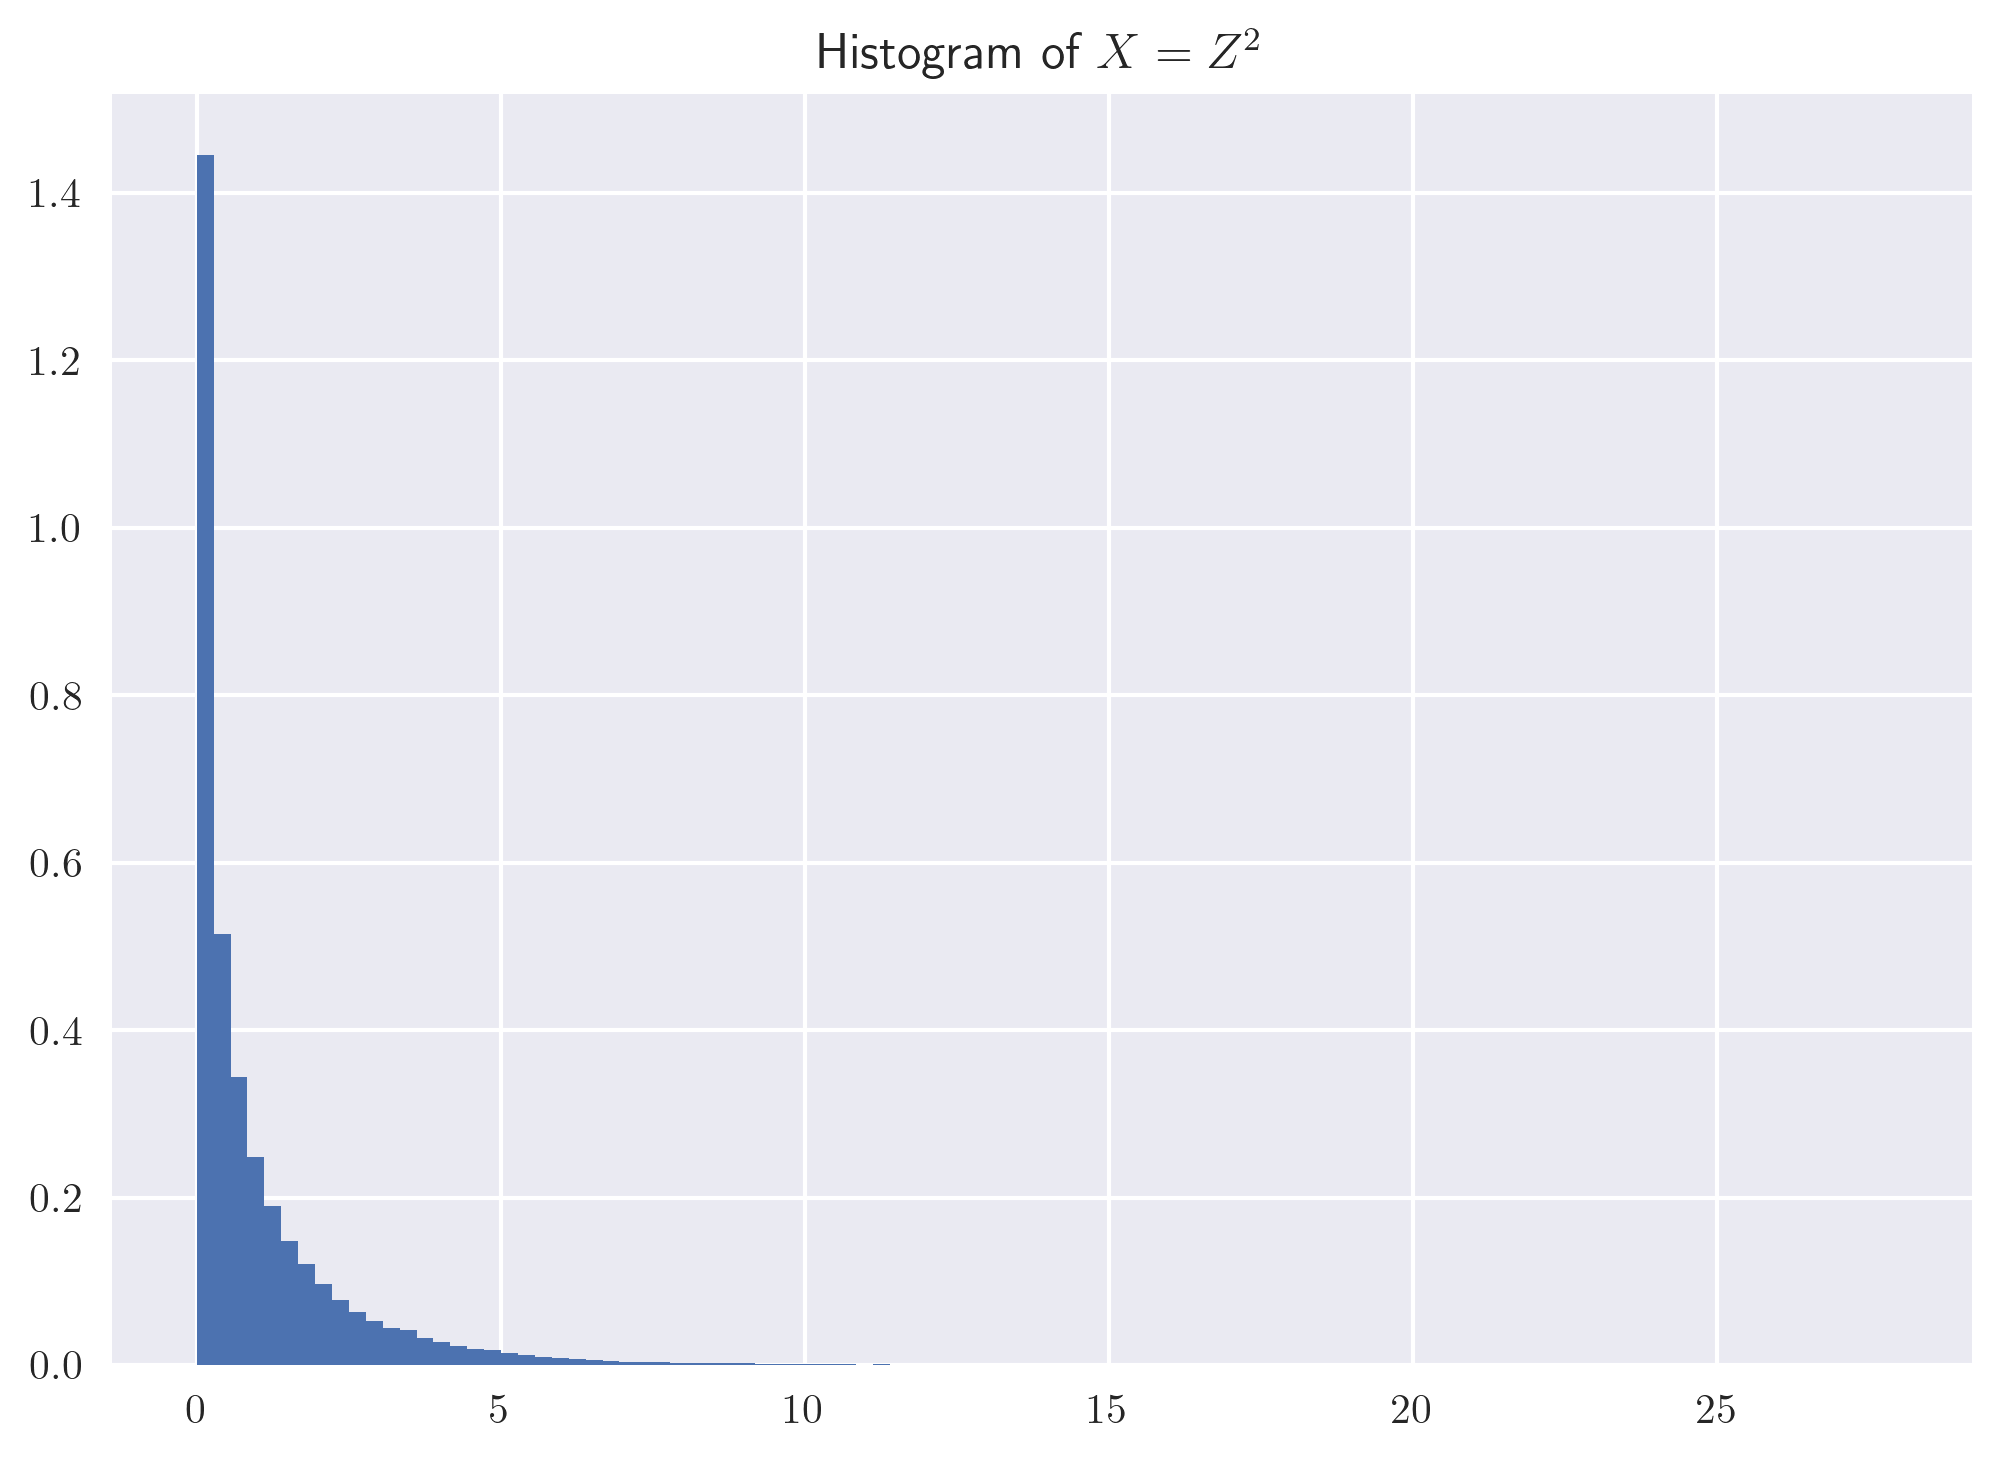

In [11]:
# Import modules
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import norm

# Use LaTeX and increase resolution
plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 300

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Generate Z
Z = norm.rvs(size = 100_000)

# Calculate X
X = Z**2

# Generate histogram; make sure density is True
plt.hist(X, bins = 100, density = True)

# Get title 
plt.title(r'Histogram of $X = Z^2$')

# Save the figure
plt.savefig(path + r'ex3-3.png')

plt.show()

### Joint Distributions

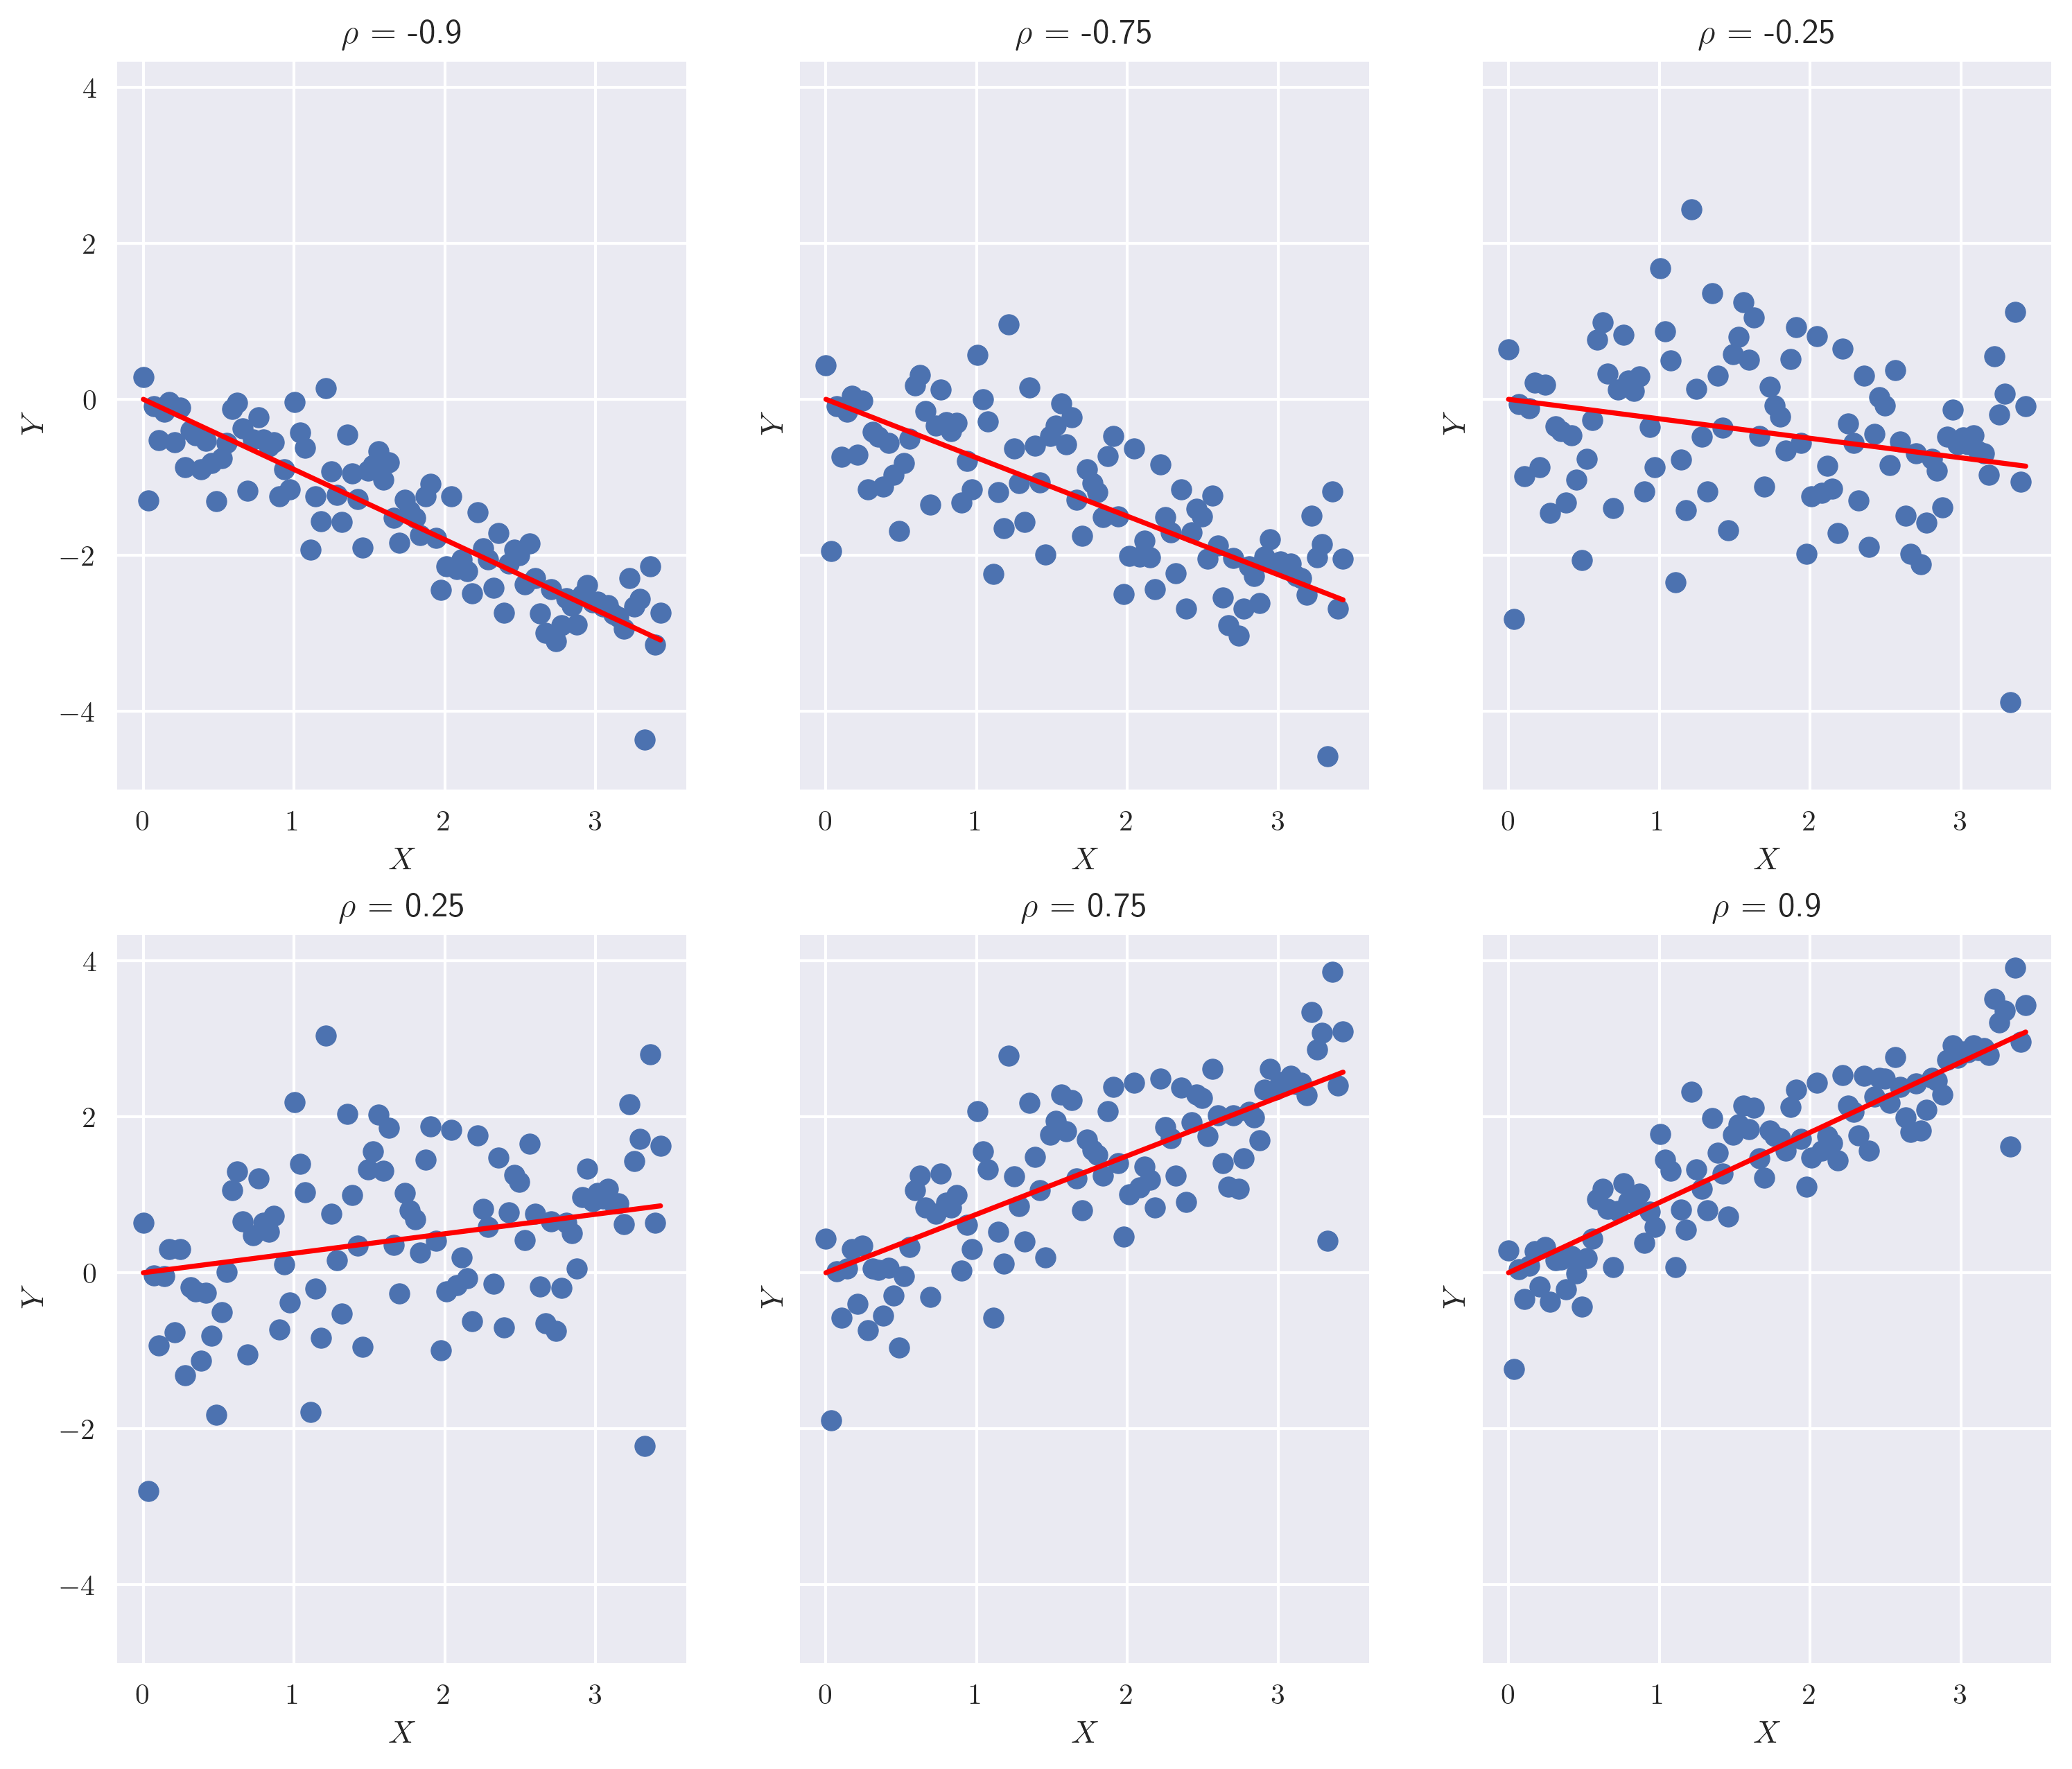

In [121]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Use LaTeX and increase resolution
plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 300

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Generate standard normals
Z = norm.rvs(size = 100)

# List correlations
rho_vals = [-0.9, -0.75, -0.25, 0.25, 0.75, 0.9]

# Set up subplots
fig, ax = plt.subplots(2, 3, sharey = True, figsize = (12, 10))

for i, rho in enumerate(rho_vals):
    
    # Get X
    X = np.linspace(0, 1, len(Z))

    # Make sure variance of X is 1
    X /= np.std(X)

    # Get Y
    Y = rho * X + np.sqrt(1 - rho**2) * Z
    
    # Get row and column
    row, col = i//3, i%3
    
    # Draw scatter plot
    ax[row, col].scatter(X, Y)
    
    # Draw plot of underlying relationship
    ax[row, col].plot(X, rho * X, color = 'red')
    
    # Add title to subplot
    ax[row, col].set_title(rf'$\rho$ = {rho}')
    
    # Add labels for x and y axes
    ax[row, col].set_xlabel(r'$X$')
    ax[row, col].set_ylabel(r'$Y$')
    
# Save the figure
plt.savefig(path + r'ex3-4.png')

plt.show()
    

### Portfolio Construction

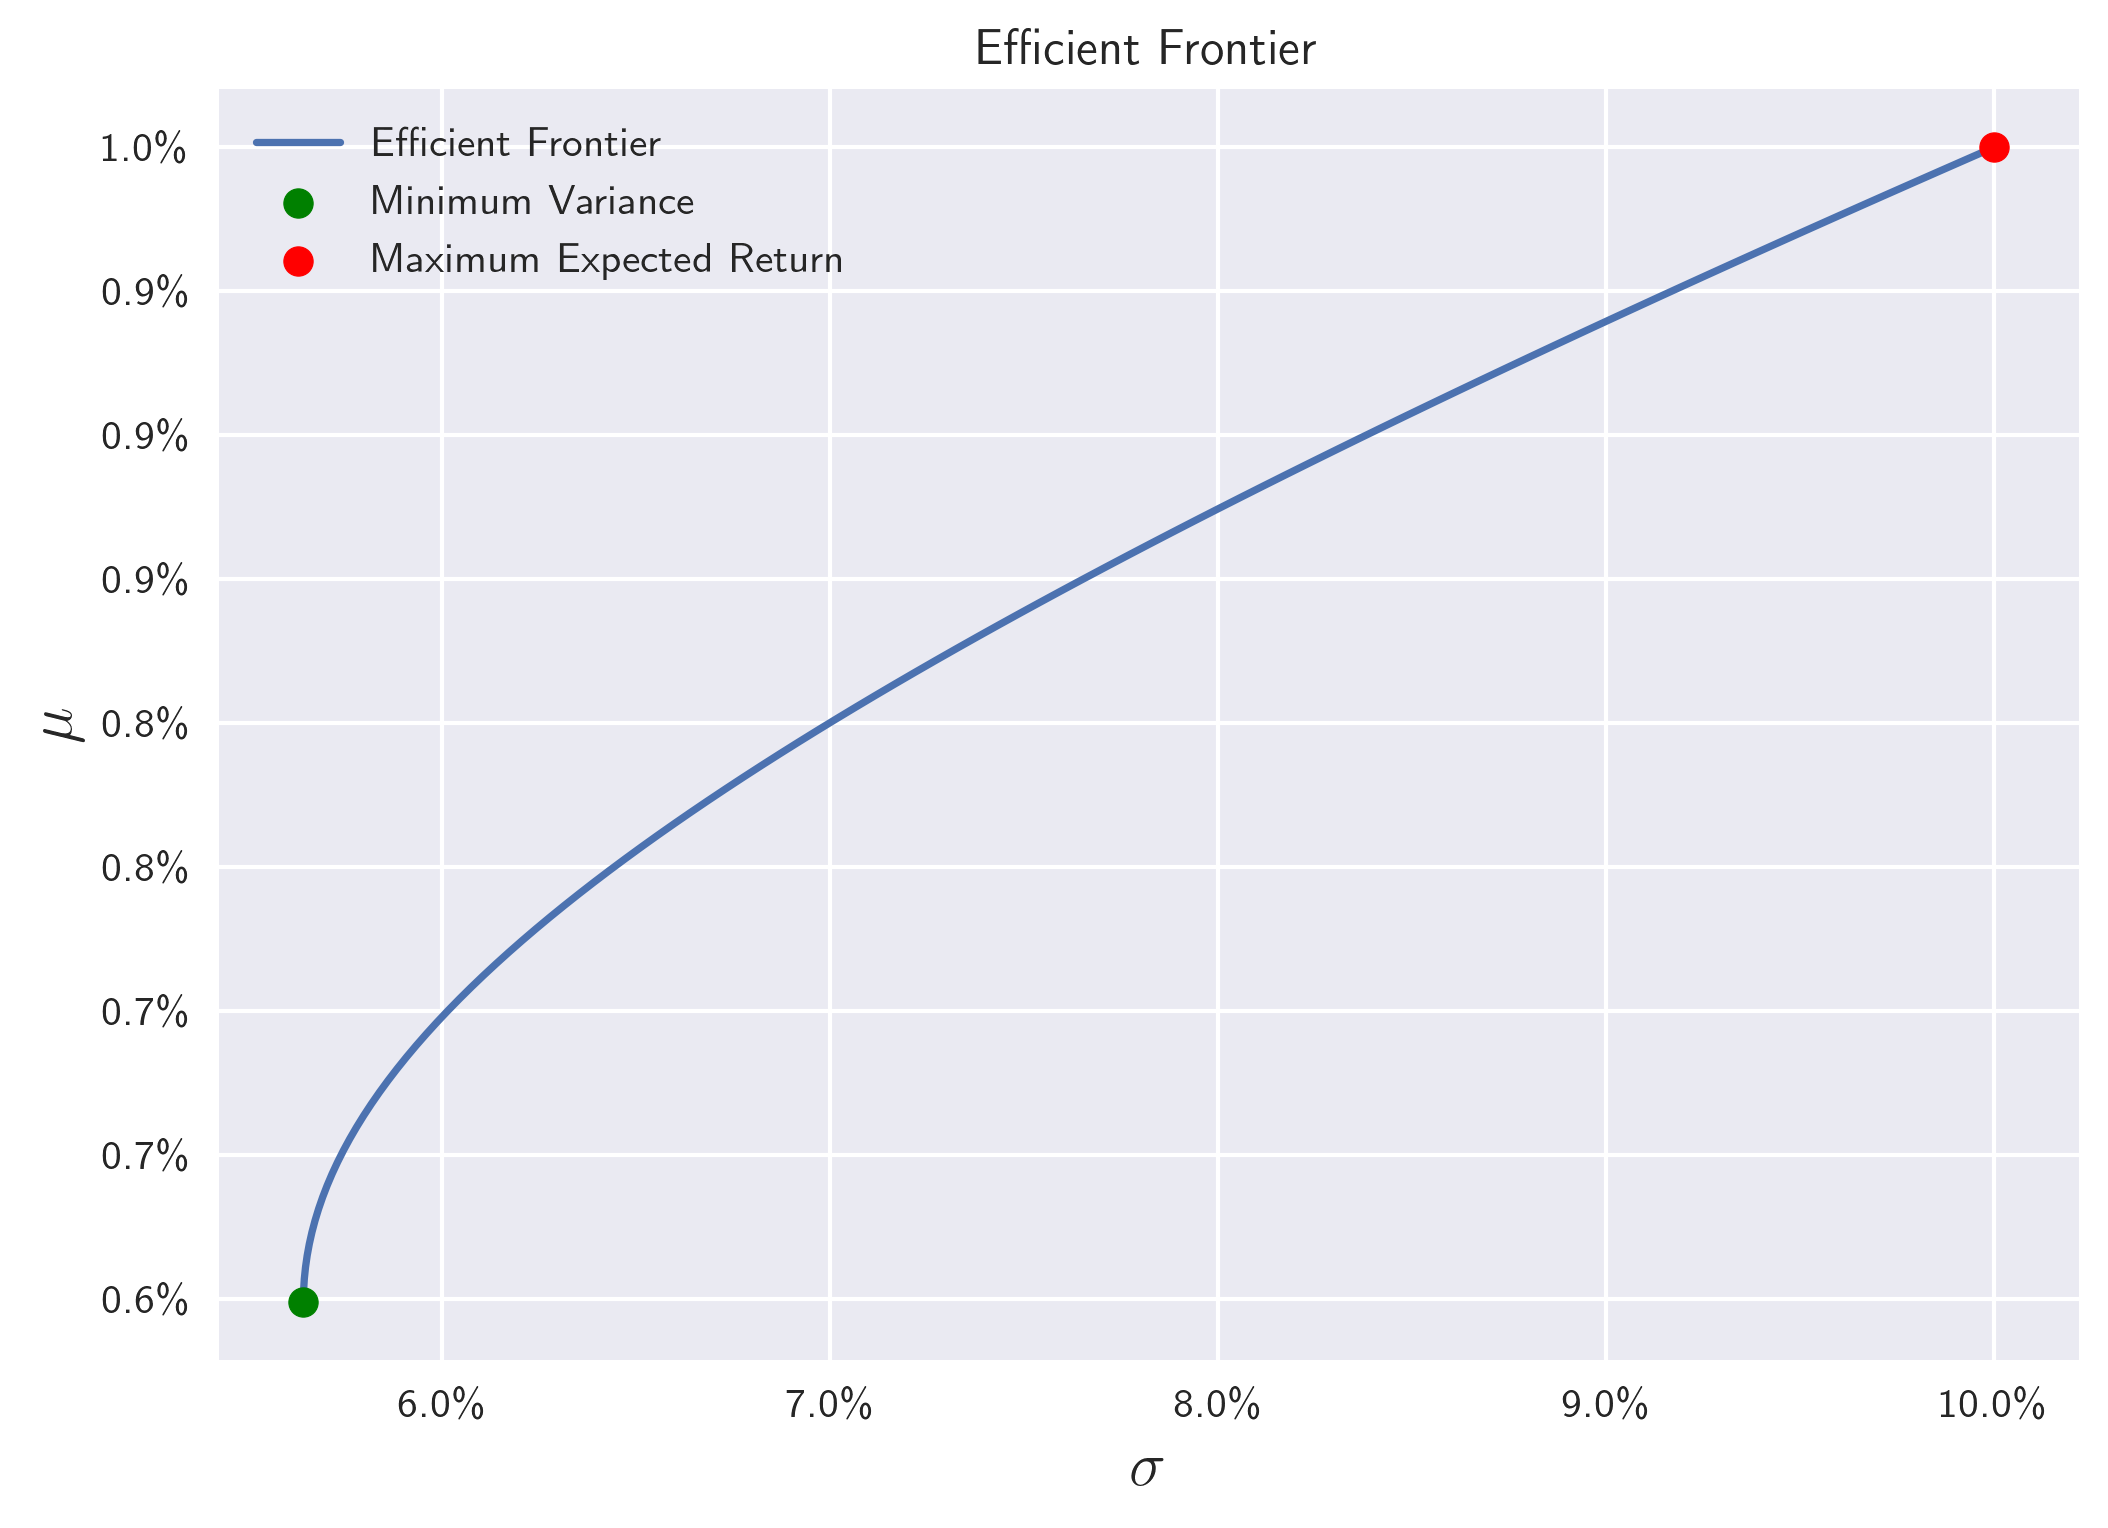

The minimum variance portfolio has respective weights in assets 1 and 2 of 19.8% and 80.2%. The standard deviation of the minimum variance portfolio is 5.6%.


In [129]:
# Import modules
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from matplotlib.ticker import PercentFormatter

# Use LaTeX and increase resolution
plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 300

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Define expected returns
mu1, mu2 = 0.01, 0.005

# Define standard deviations
sigma1, sigma2 = 0.10, 0.06

# Define correlation
rho = 0.25

# Create function for portfolio expected return
port_mu = lambda w: mu1 * w + mu2 * (1 - w)

# Create function for portfolio standard deviations
def port_sigma(w):
    
    # Calculate variance...
    
    # ... uncorrelated variance
    var = w**2 * sigma1**2 + (1 - w)**2 * sigma2**2 
    
    # ... variance due to correlation
    var +=  2 * w * (1 - w) * rho * sigma1 * sigma2
    
    # Take square root to obtain standard deviation
    return np.sqrt(var)

# Get weights for minimum variance portfolio; no short positions
w_min_var = minimize_scalar(port_sigma, bounds = (0, 1), 
                            method = 'bounded').x

# Define number of samples
samples = 100

# Get weights
wt_vals = np.linspace(w_min_var, 1.0, samples)

# Calculate expected returns for each wt
mu_vals = port_mu(wt_vals)

# Calculate std of returns for each wt
sigma_vals = port_sigma(wt_vals)

# Stack results, so dimension (-1, 2)
port_results = np.column_stack([mu_vals, sigma_vals])

# Convert to data frame
port_results = pd.DataFrame(port_results, 
                            columns = ['mu', 'sigma'])

# Plot efficient frontier
plt.plot(port_results['sigma'], port_results['mu'], 
         label = 'Efficient Frontier')

# Add dot for minimum variance portfolio
plt.scatter(port_results.loc[0, 'sigma'], port_results.loc[0, 'mu'], 
            label = 'Minimum Variance', color = 'green',
            zorder = 3)

# Add dot for maximum expected return
plt.scatter(port_results.loc[samples - 1, 'sigma'], 
            port_results.loc[samples - 1, 'mu'], 
            label = 'Maximum Expected Return', color = 'red',
            zorder = 3)

# Add legend
plt.legend()

# Add x-label
plt.xlabel(r'$\sigma$', fontsize = 15)

# Add y-label
plt.ylabel(r'$\mu$', fontsize = 15)

# Add title
plt.title('Efficient Frontier')

# Write both axes as a percentage
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0, decimals = 1))
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0, decimals = 1))

# Save the figure
plt.savefig(path + r'ex3-5.png')

plt.show()

print(r'The minimum variance portfolio has respective weights in', 
      rf'assets 1 and 2 of {100 * w_min_var:.1f}% and {100 - 100 * w_min_var:.1f}%.',
     f'The standard deviation of the minimum variance portfolio is {100 * port_sigma(w_min_var):.1f}%.')
      

## Statistics
### Law of Large Numbers

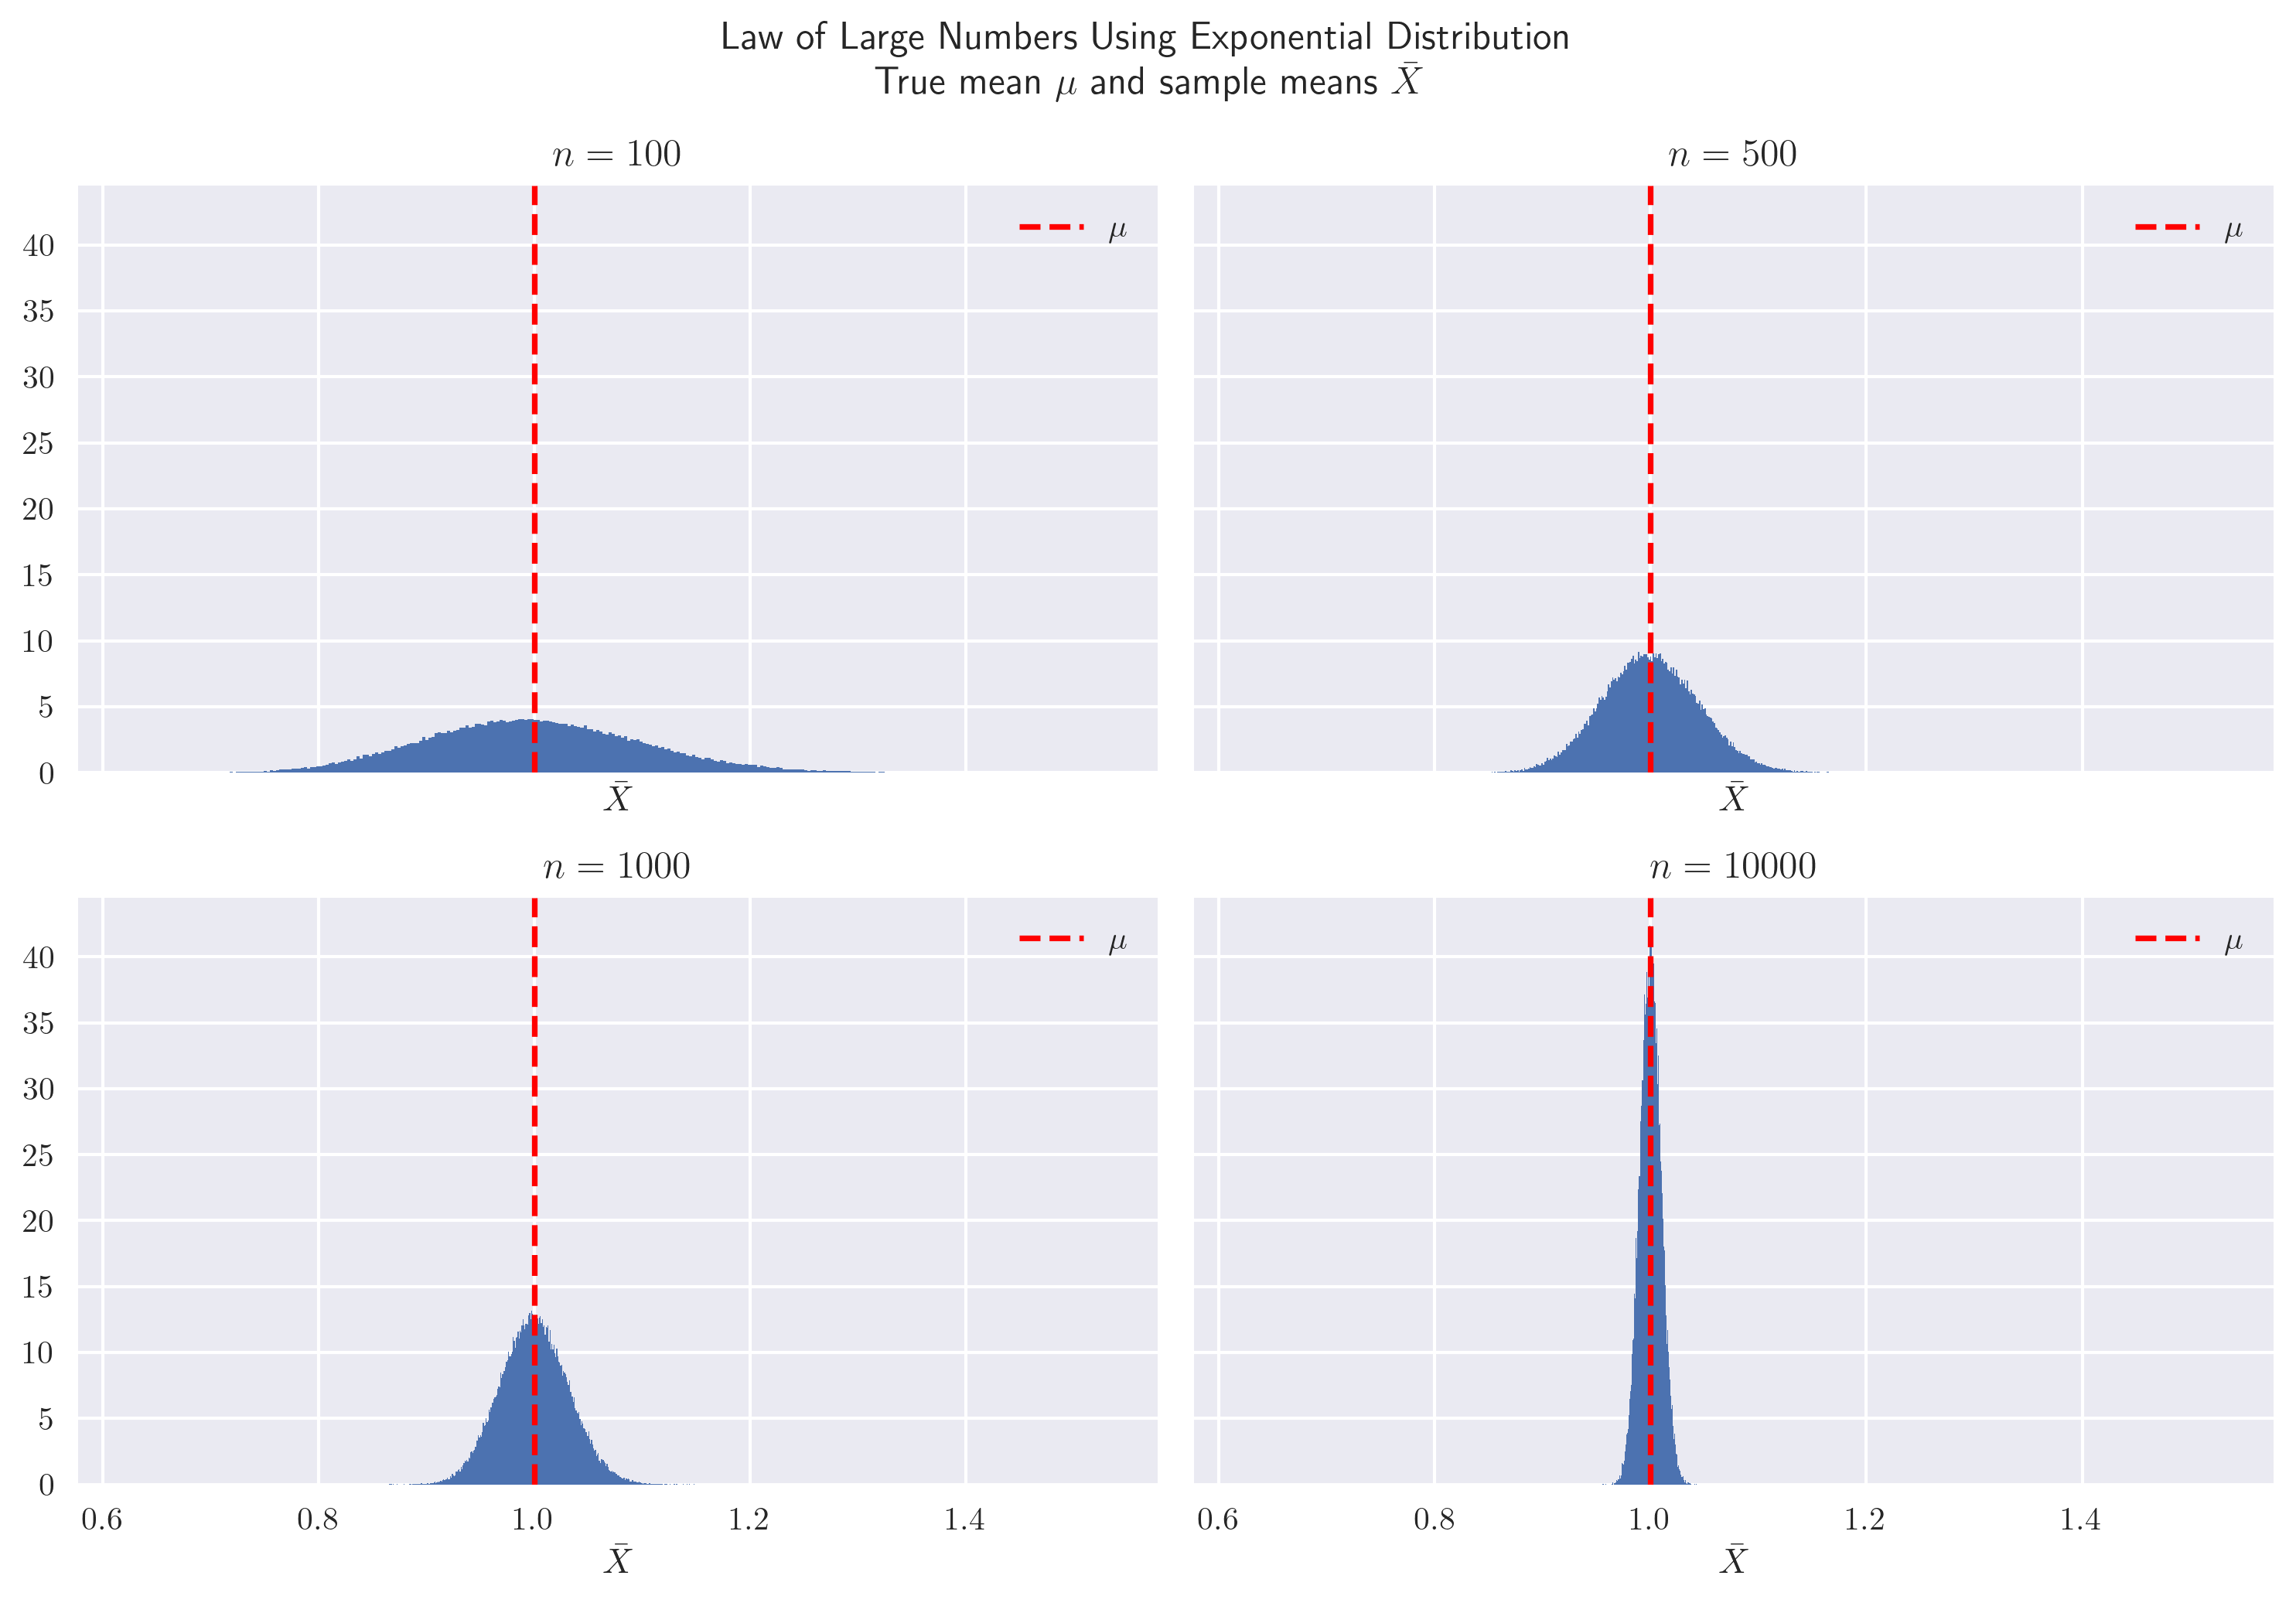

This program took 16.422 seconds.


In [13]:
# Import modules
import numpy as np, matplotlib.pyplot as plt, time
from scipy.stats import expon

# Start the clock!
start_time = time.perf_counter()

# Use LaTeX
plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 300

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Set random seed
np.random.seed(0)

# Choose n-values and set number of trials
n_vals, trials = [100, 500, 1000, 10_000], 100_000

# Define the number of bins
num_bins = int(np.sqrt(trials))

# Define the mu
lam = 1

# Set up subplots
fig, ax = plt.subplots(2, 2, sharex = True, sharey = True, 
                       figsize = (10, 7))

for i, n in enumerate(n_vals):

    # Get row and column
    nrow, ncol = i // 2, i % 2
    
    # Generate numbers of dimension n x trails
    # Scale is mu = 1/lambda; default is 1 so unnecessary
    X = expon.rvs(scale = 1/lam, size = (n, trials))  
    
    # Take mean of each row and make histogram
    ax[nrow, ncol].hist(X.mean(axis = 0), bins = num_bins, density = True)

    # Add verticle line at expected value
    ax[nrow, ncol].axvline(x = 1/lam, linestyle = 'dashed', 
           color = 'red', label = r'$\mu$')
    
    # Give each histogram a title
    ax[nrow, ncol].title.set_text(f'$n = {n}$')
    
    # Add legend
    ax[nrow, ncol].legend()

    # Set x-axis label
    ax[nrow, ncol].set_xlabel(r'$\bar{X}$')

# Clear up a little RAM
del X

# Give the entire figure a title
fig.suptitle(r'Law of Large Numbers Using Exponential Distribution' 
             +'\n' + r'True mean $\mu$ and sample means $\bar{X}$')

# Change padding on figure
plt.tight_layout()

plt.show()

# When my programs run slowly, I like to monitor the time it takes
print(f'This program took {time.perf_counter() - start_time:.3f} seconds.')

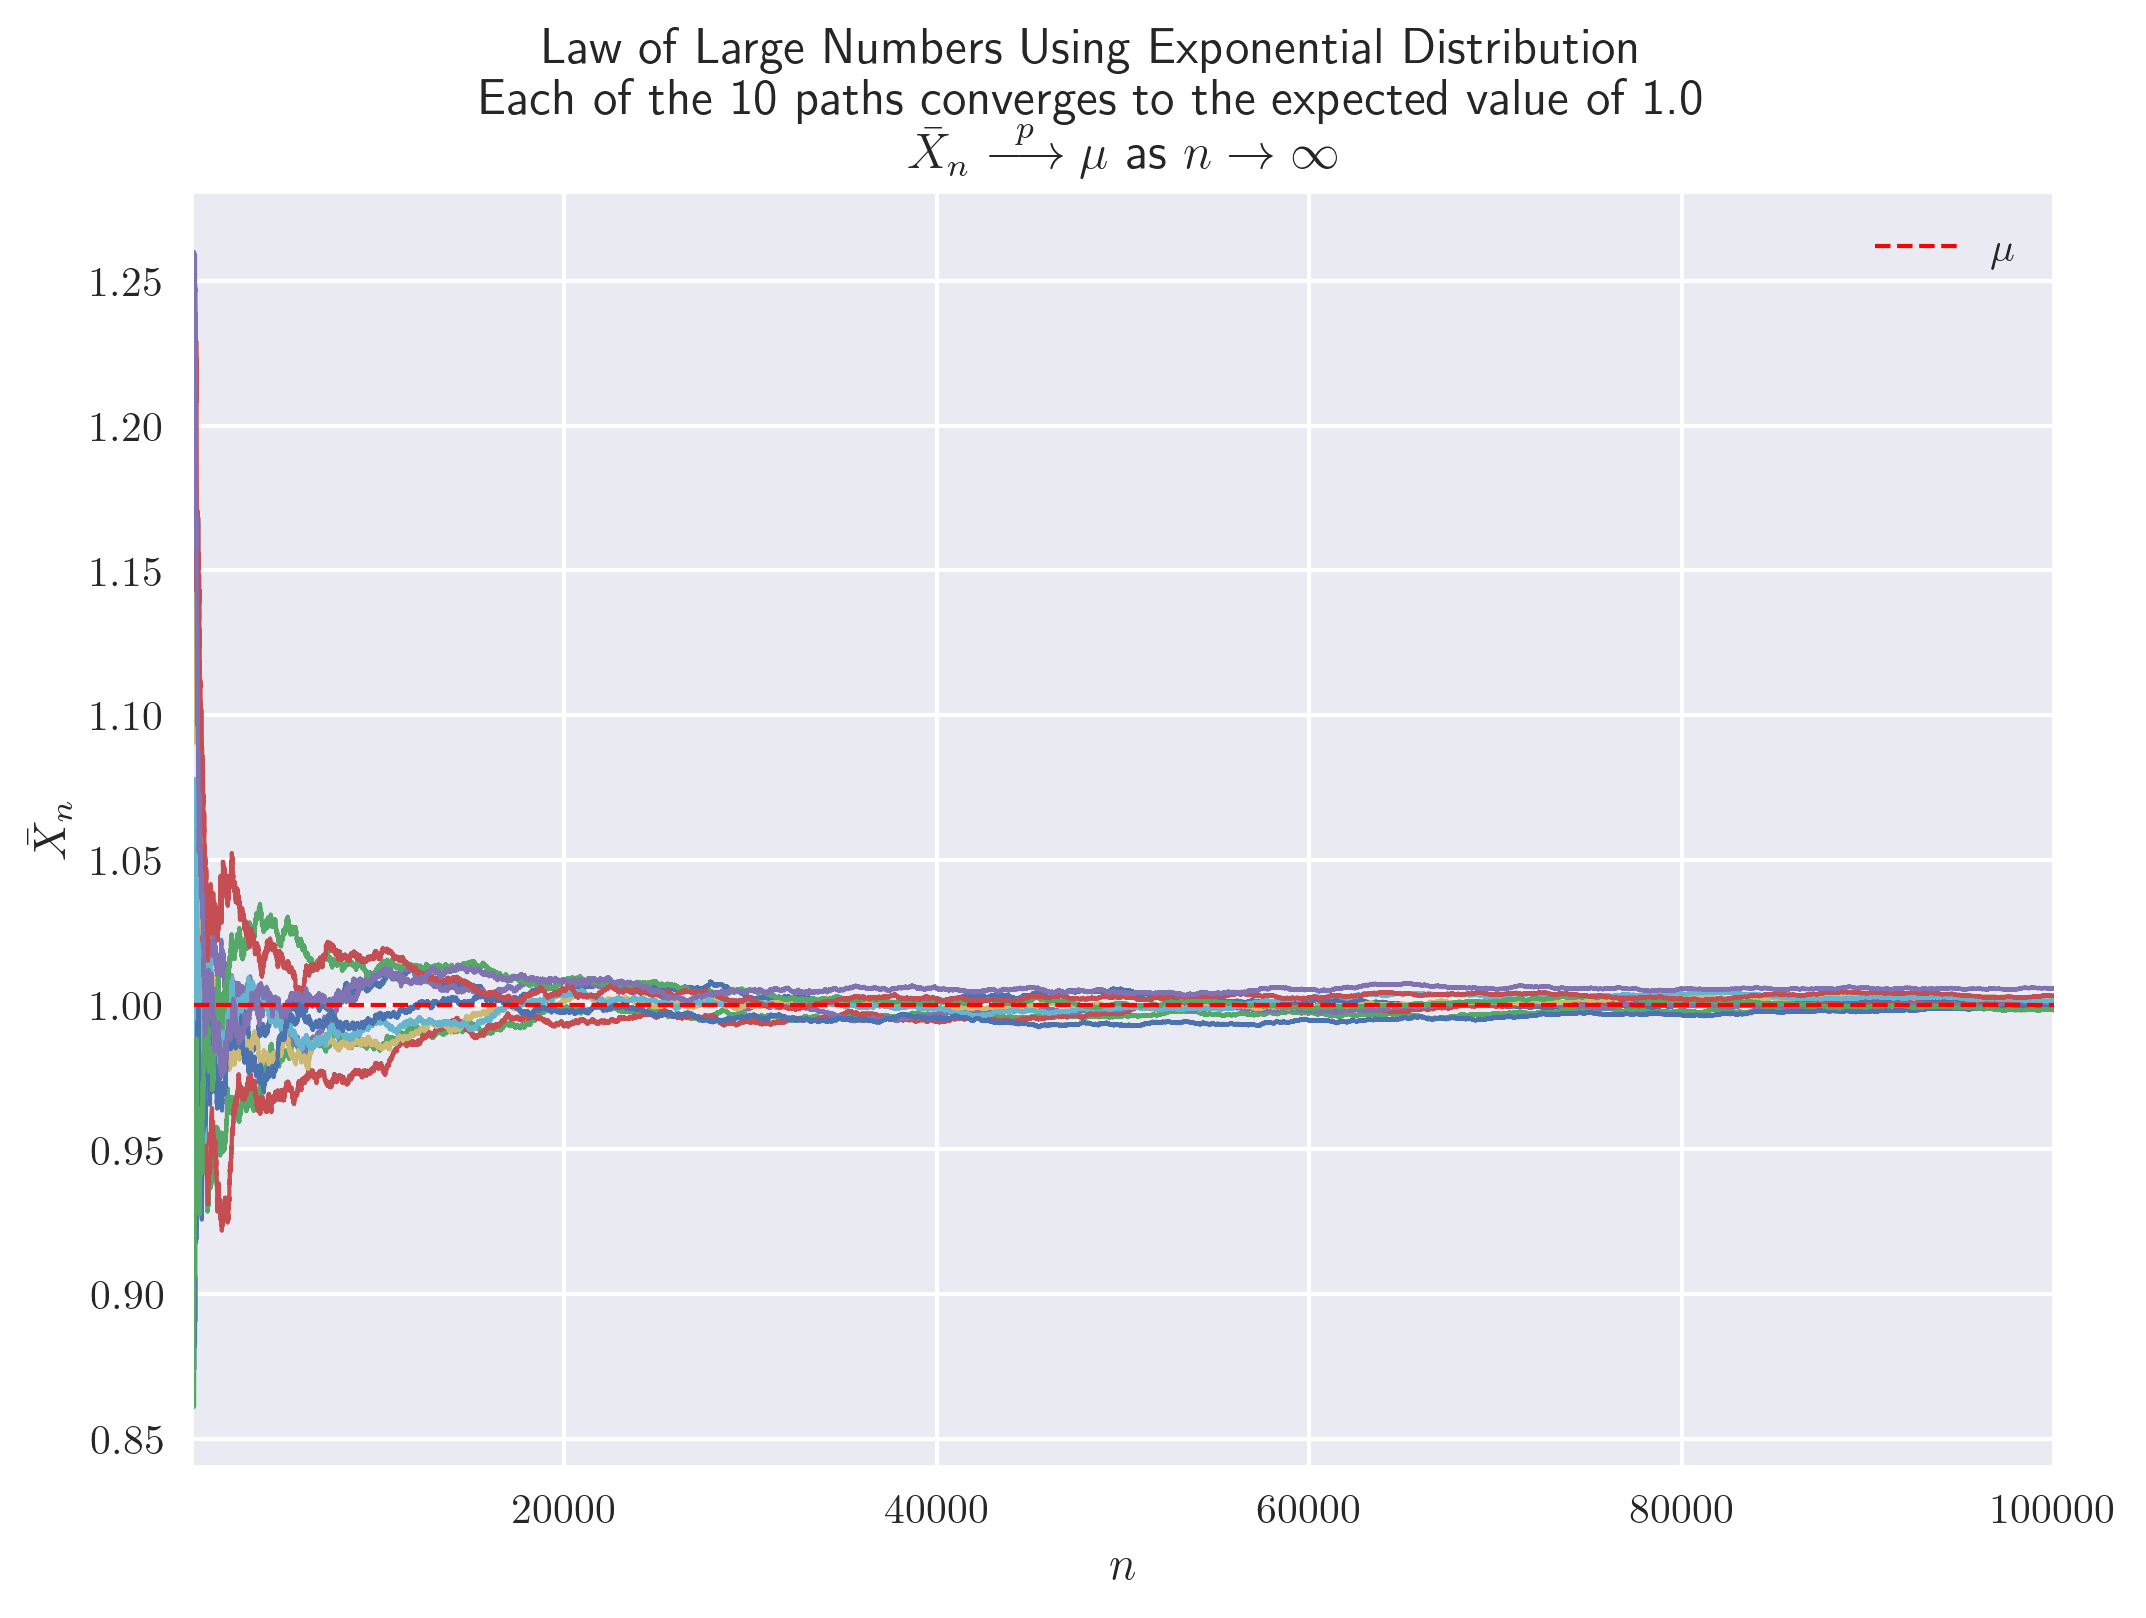

In [143]:
# Import modules
import numpy as np, matplotlib.pyplot as plt, time
from scipy.stats import expon

# Use LaTeX and increase resolution
plt.rcParams['text.usetex'], plt.rcParams['figure.dpi'] = True, 300

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Set random seed
np.random.seed(0)

# Define lambda
lam = 1

# Generate exponentials; mu is scale = 1/lambda for exponential
X = expon.rvs(scale = 1/lam, size = (100_000, 10))

# Define n-values
n_vals = np.arange(1, X.shape[0] + 1)

# Calculate cumulative sample means
X = X.cumsum(axis = 0)
X = X/n_vals[:, np.newaxis]

# Define the minimum n on the plots
min_n_val = 100

# Only interested in observations after the first 100
X = X[min_n_val - 1:, :]
n_vals = n_vals[min_n_val - 1:]

# Plot results
plt.plot(n_vals, X, linewidth = 1)

# Add dashed line for expected value
plt.axhline(y = 1/lam, linewidth = 1, linestyle = 'dashed', 
           color = 'red', label = r'$\mu$')

# Add label to x-axis
plt.xlabel('$n$')

# Add label to y-axis
plt.ylabel(r'$\bar{X}_n$')

# Add legend
plt.legend()

# Give plot a title
plt.suptitle(f'Law of Large Numbers Using Exponential Distribution\n Each of the {X.shape[1]} paths converges to the expected value of {1/lam}')

# Add a subtitle
plt.title(r'$\bar{X}_n\stackrel{p}{\longrightarrow} \mu$ as $n\to \infty$')

# Change the horizontal axis limits
plt.xlim(min_n_val, n_vals.max())

# Save the figure
plt.savefig(path + r'ex3-6.png')

plt.show()

# Clear RAM
del X


### Empirical CDFs

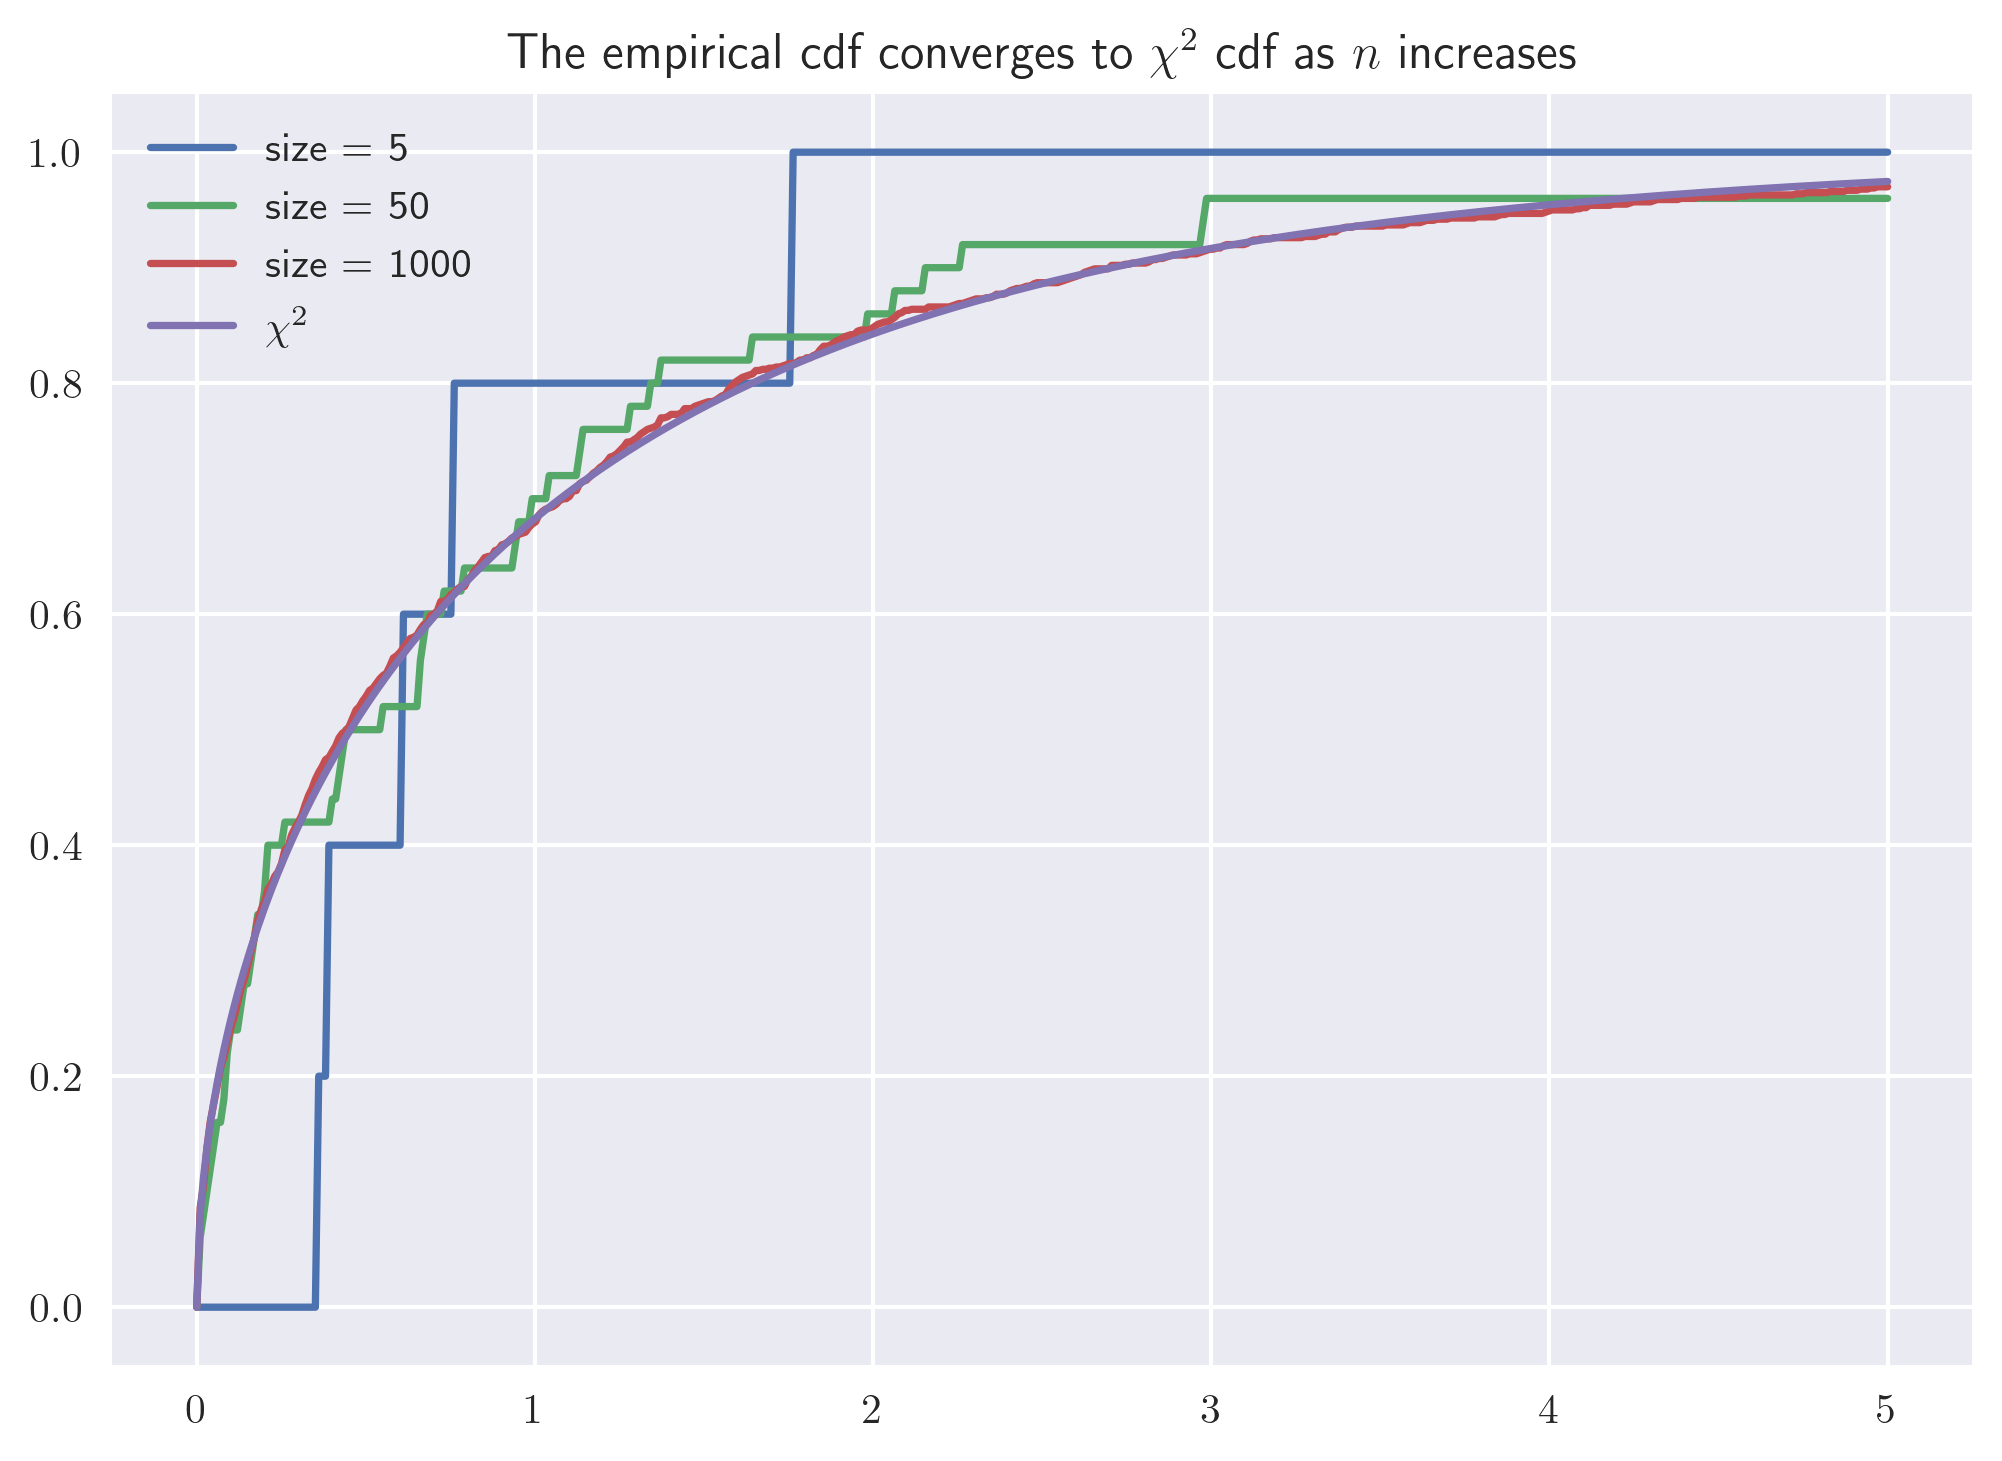

In [20]:
# Import modules
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import chi2

# Use LaTeX and increase resolution
plt.rcParams['text.usetex'],  plt.rcParams['figure.dpi'] = True, 300

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Set random seed
np.random.seed(0)

# Create empirical cdf
ecdf = lambda x, sample: np.mean(sample <= x)

# List of sample sizes
sample_sizes = [5, 50, 1000]

# Create x-values for plot
x_vals = np.linspace(0, 5, 500)

# Loop over the sample sizes
for sample_size in sample_sizes:
    
    # Generate sample
    sample = chi2.rvs(df = 1, size = sample_size)
    
    # Get the y-values
    y_vals = [ecdf(x, sample) for x in x_vals]
    
    # Plot values
    plt.plot(x_vals, y_vals, label = f'size = {sample_size}')

# Get y-values; function vectorized
y_vals = chi2.cdf(x_vals, df = 1)

# Plot chi^2 cdf
plt.plot(x_vals, y_vals, label = r'$\chi^2$')

# Clear up RAM
del sample, x_vals, y_vals

# Show legend
plt.legend()

# Add title
plt.title(r'The empirical cdf converges to $\chi^2$ cdf as $n$ increases')

# Save the figure
plt.savefig(path + r'ex3-7.png')

plt.show()

### Central Limit Theorem

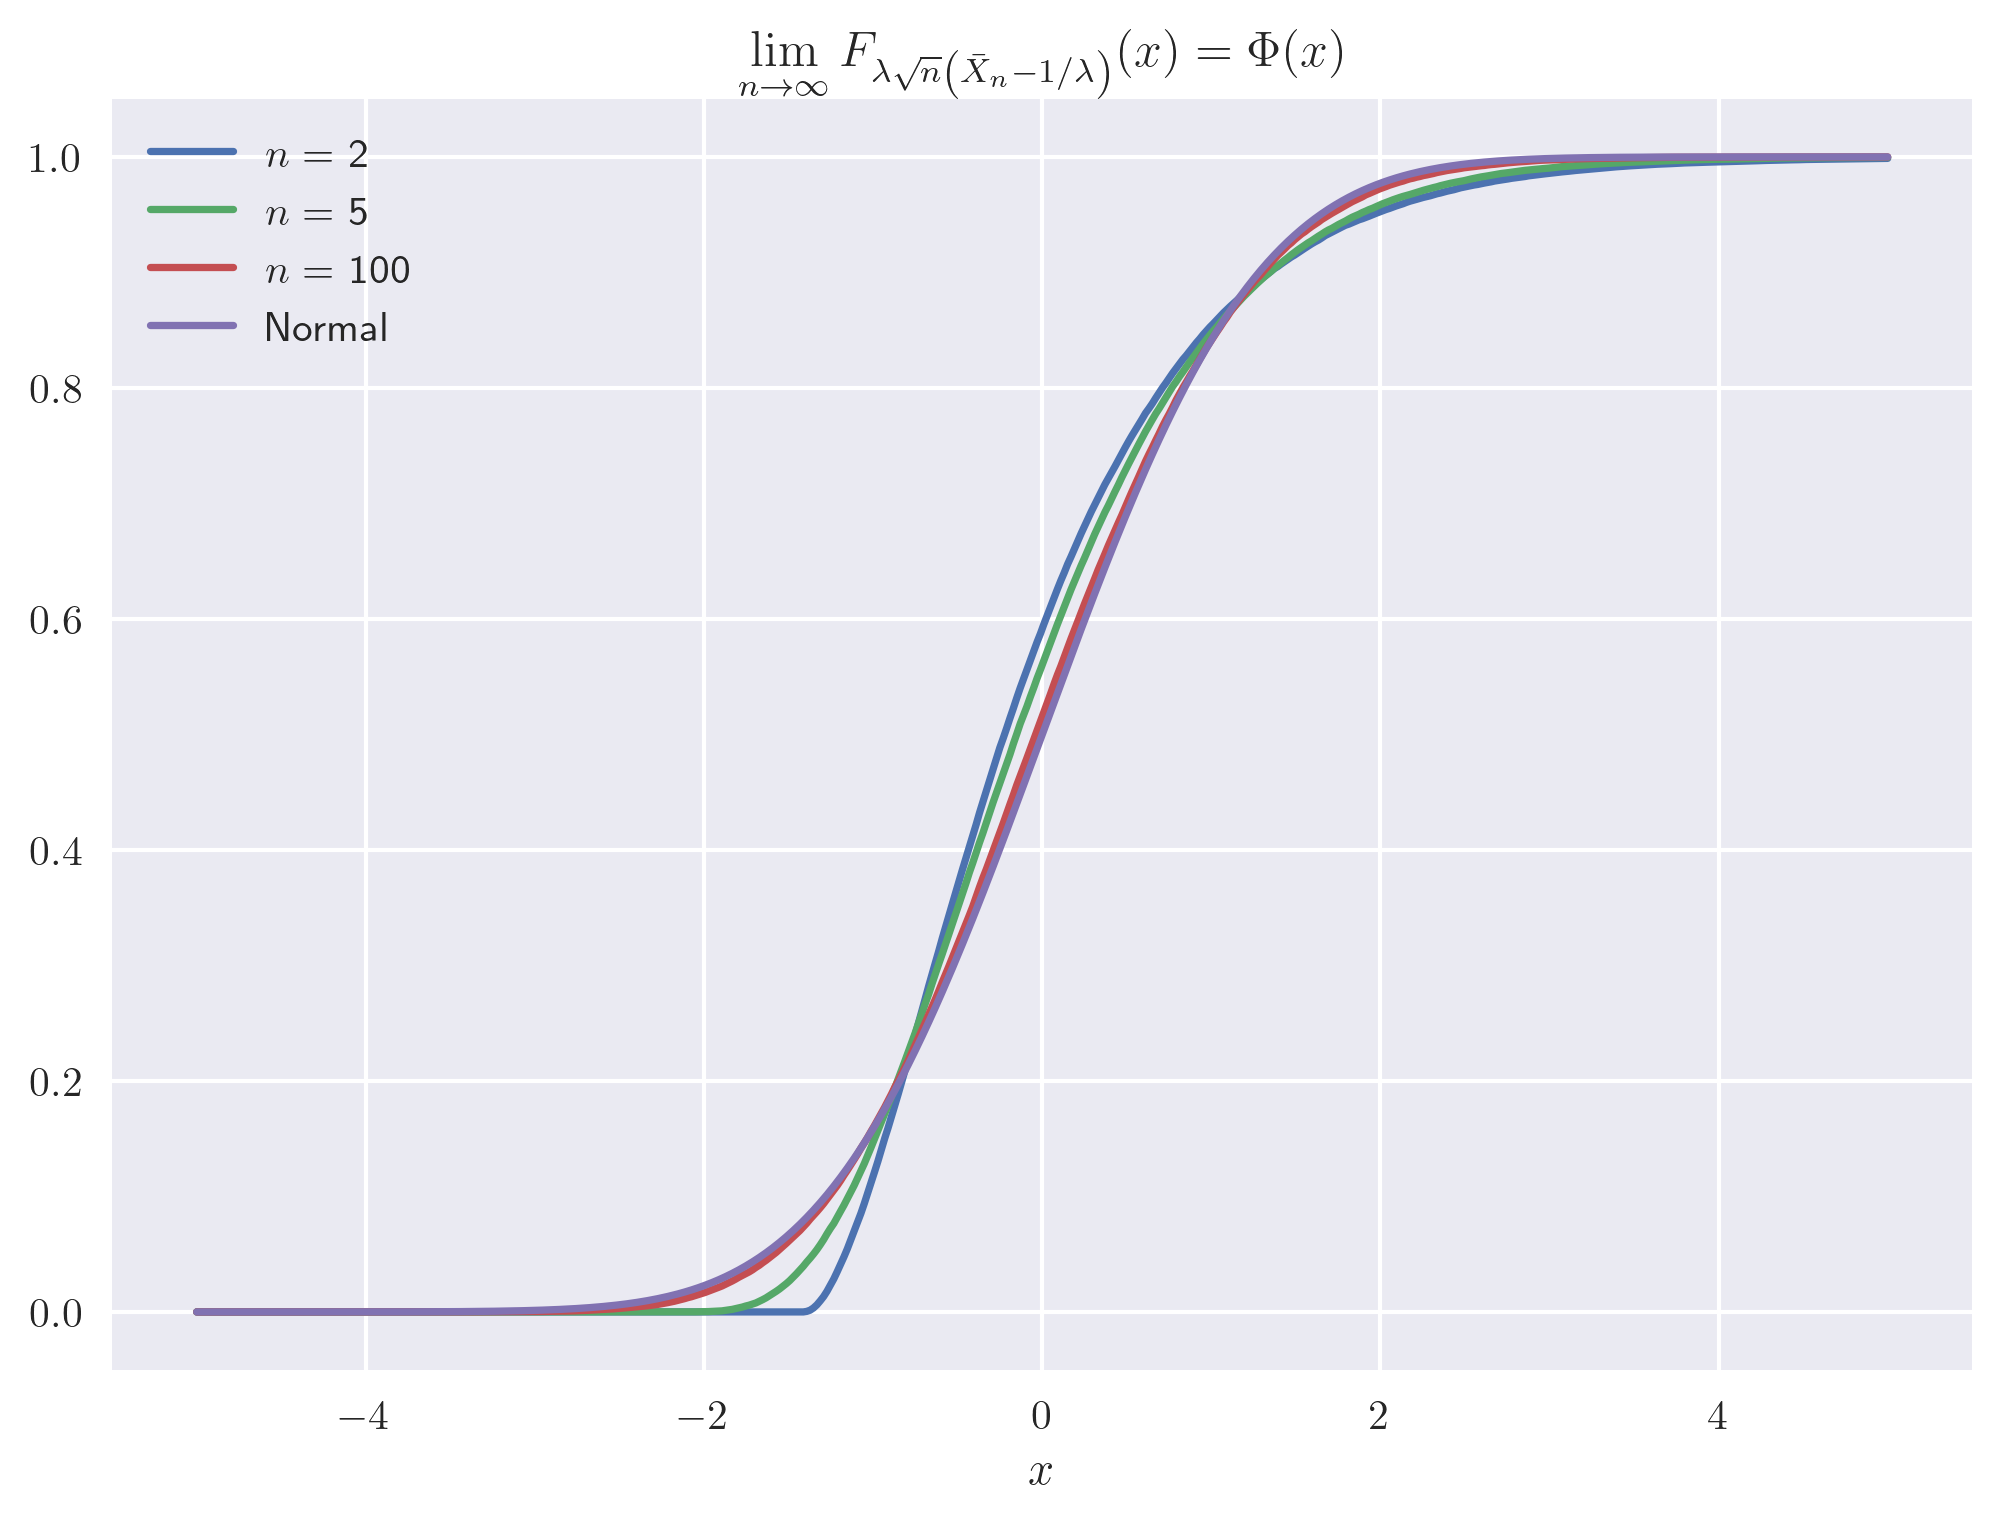

In [16]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon, norm

# Use LaTeX
plt.rcParams['text.usetex'] = True

# Increase resolution
plt.rcParams['figure.dpi'] = 300

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Set random seed
np.random.seed(0)

# Create empirical cdf
ecdf = lambda x, sample: np.mean(sample <= x)

# Create x-values for plot
x_vals = np.linspace(-5, 5, 500)

# Create n-values
n_vals = [2, 5, 100]

# Let's do 100,000 trials
trials = 100_000

# Scale is 1/lambda
lam = 1

# Loop over the n-values
for n in n_vals:
    
    # Generate the sample; mean is 1/lam and std is 1/lam
    sample =  expon.rvs(scale = 1/lam, size = (n, trials)).mean(axis = 0)
    
    # Change sample so it has mean 0 and sd 1; current mean 1/lam and sd 1/(lam * sqrt(n))
    sample = np.sqrt(n)/(1/lam) * (sample - 1/lam)
    
    # Get y-values
    y_vals = [ecdf(x, sample) for x in x_vals]
    
    # Plot values
    plt.plot(x_vals, y_vals, label = f'$n =$ {n}')

# Get y-values
y_vals = norm.cdf(x_vals)

# Plot standard normal cdf
plt.plot(x_vals, y_vals, label = 'Normal')

# Add x-axis label
plt.xlabel('$x$')

# Show legend
plt.legend()

# Add title
plt.title(r'$\displaystyle\lim_{n\to\infty}F_{\lambda\sqrt{n}\left(\bar{X}_n - 1/\lambda\right)}(x) = \Phi(x)$')

# Save the figure
plt.savefig(path + r'ex3-8.png')

plt.show()

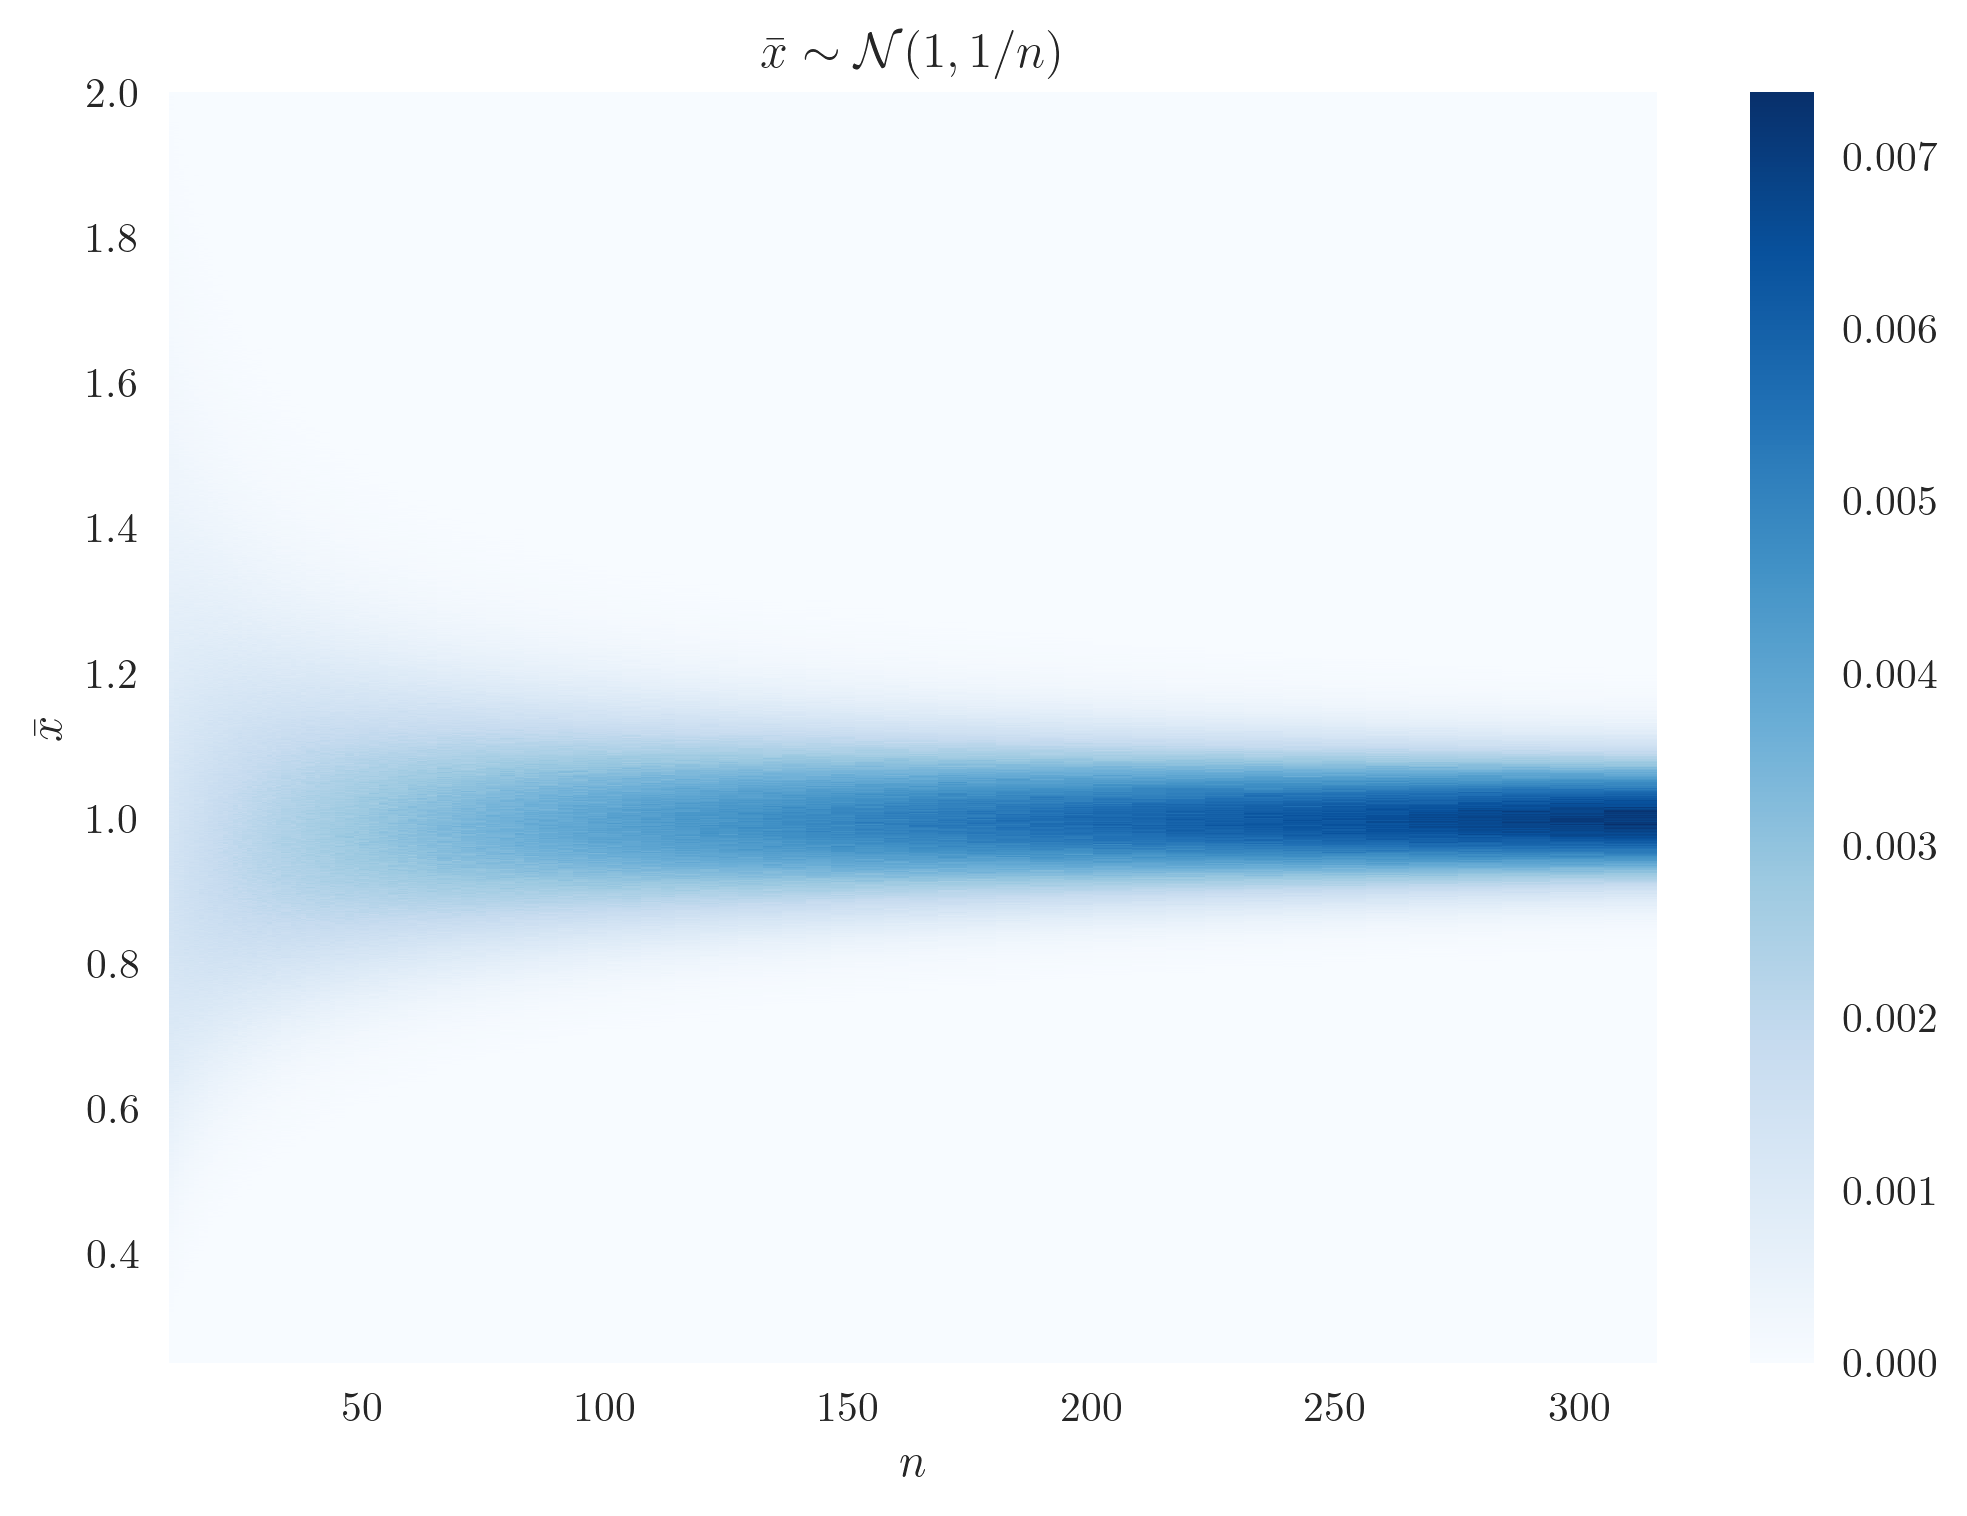

This program took 1.66 minutes.


In [18]:
# Import modules
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import time

# Use LaTeX
plt.rcParams['text.usetex'] = True

# Start the clock
start_time = time.perf_counter()

# Get array of n values to use; repeats at beginning fine
# Good to sample higher variance part more
num_vals = np.logspace(1, 2.5, 100).astype(int)

# Define number of runs
num_runs = 500_000

# Initialize list to hold exprimental values
exprimental_values = []

for n in num_vals:
        
    # Generate exponential values and take the average of columns
    dist = stats.expon.rvs(size = (n, num_runs)).mean(axis = 0)
    
    # Add column to denote n used in average
    result = np.concatenate([np.repeat(n, num_runs).reshape(1, -1), 
                             dist.reshape(1, -1)], axis = 0).T
        
    # Record results
    exprimental_values.extend(result)
        
# Convert to a pandas data frame
exprimental_values = pd.DataFrame(exprimental_values, columns = ['num', 'mean'])

# Rework so we get normalized frequencies
exprimental_values['count'] = 1

# Discretize mean
exprimental_values['mean'] = exprimental_values['mean'].round(3)

# Count number of elements in each bin
exprimental_values = exprimental_values.groupby(['num', 'mean'])['count'].sum().reset_index()

# Rows are the mean, columns are the number of elements averaged, entry is the count
exprimental_values = exprimental_values.pivot(index = 'mean', columns = 'num', values = 'count') 

# Fill empty values with zero
exprimental_values= exprimental_values.fillna(0)

# Divide by the sum of the column      
exprimental_values = exprimental_values.div(exprimental_values.sum(axis = 0), axis = 1)

# Sort values
exprimental_values = exprimental_values.sort_index(ascending = False)

# Get figure and axes
fig, ax = plt.subplots()

# Convert to grid
X, Y = np.meshgrid(exprimental_values.columns, exprimental_values.index)

# Get the frequency numbers
Z = exprimental_values.values[1:, 1:]

# Generate the pcolormesh
c = ax.pcolormesh(X, Y, Z, cmap = 'Blues')

# Add a color bar
fig.colorbar(c, ax = ax)

# Add a title
ax.set_title(r'$\bar{x}\sim{\mathcal{N}(1, 1/n)}$')

# Add axis labels
ax.set_xlabel('$n$')
ax.set_ylabel(r'$\bar{x}$')

# Set y limits
ax.set_ylim(0.25, 2)

# Show the figure
plt.show()

# Clear up RAM
del exprimental_values, X, Y, Z

# I like to monitor how long it takes slow code to run
print(f'This program took {(time.perf_counter() - start_time)/60:0.2f} minutes.')

### Hypothesis Testing

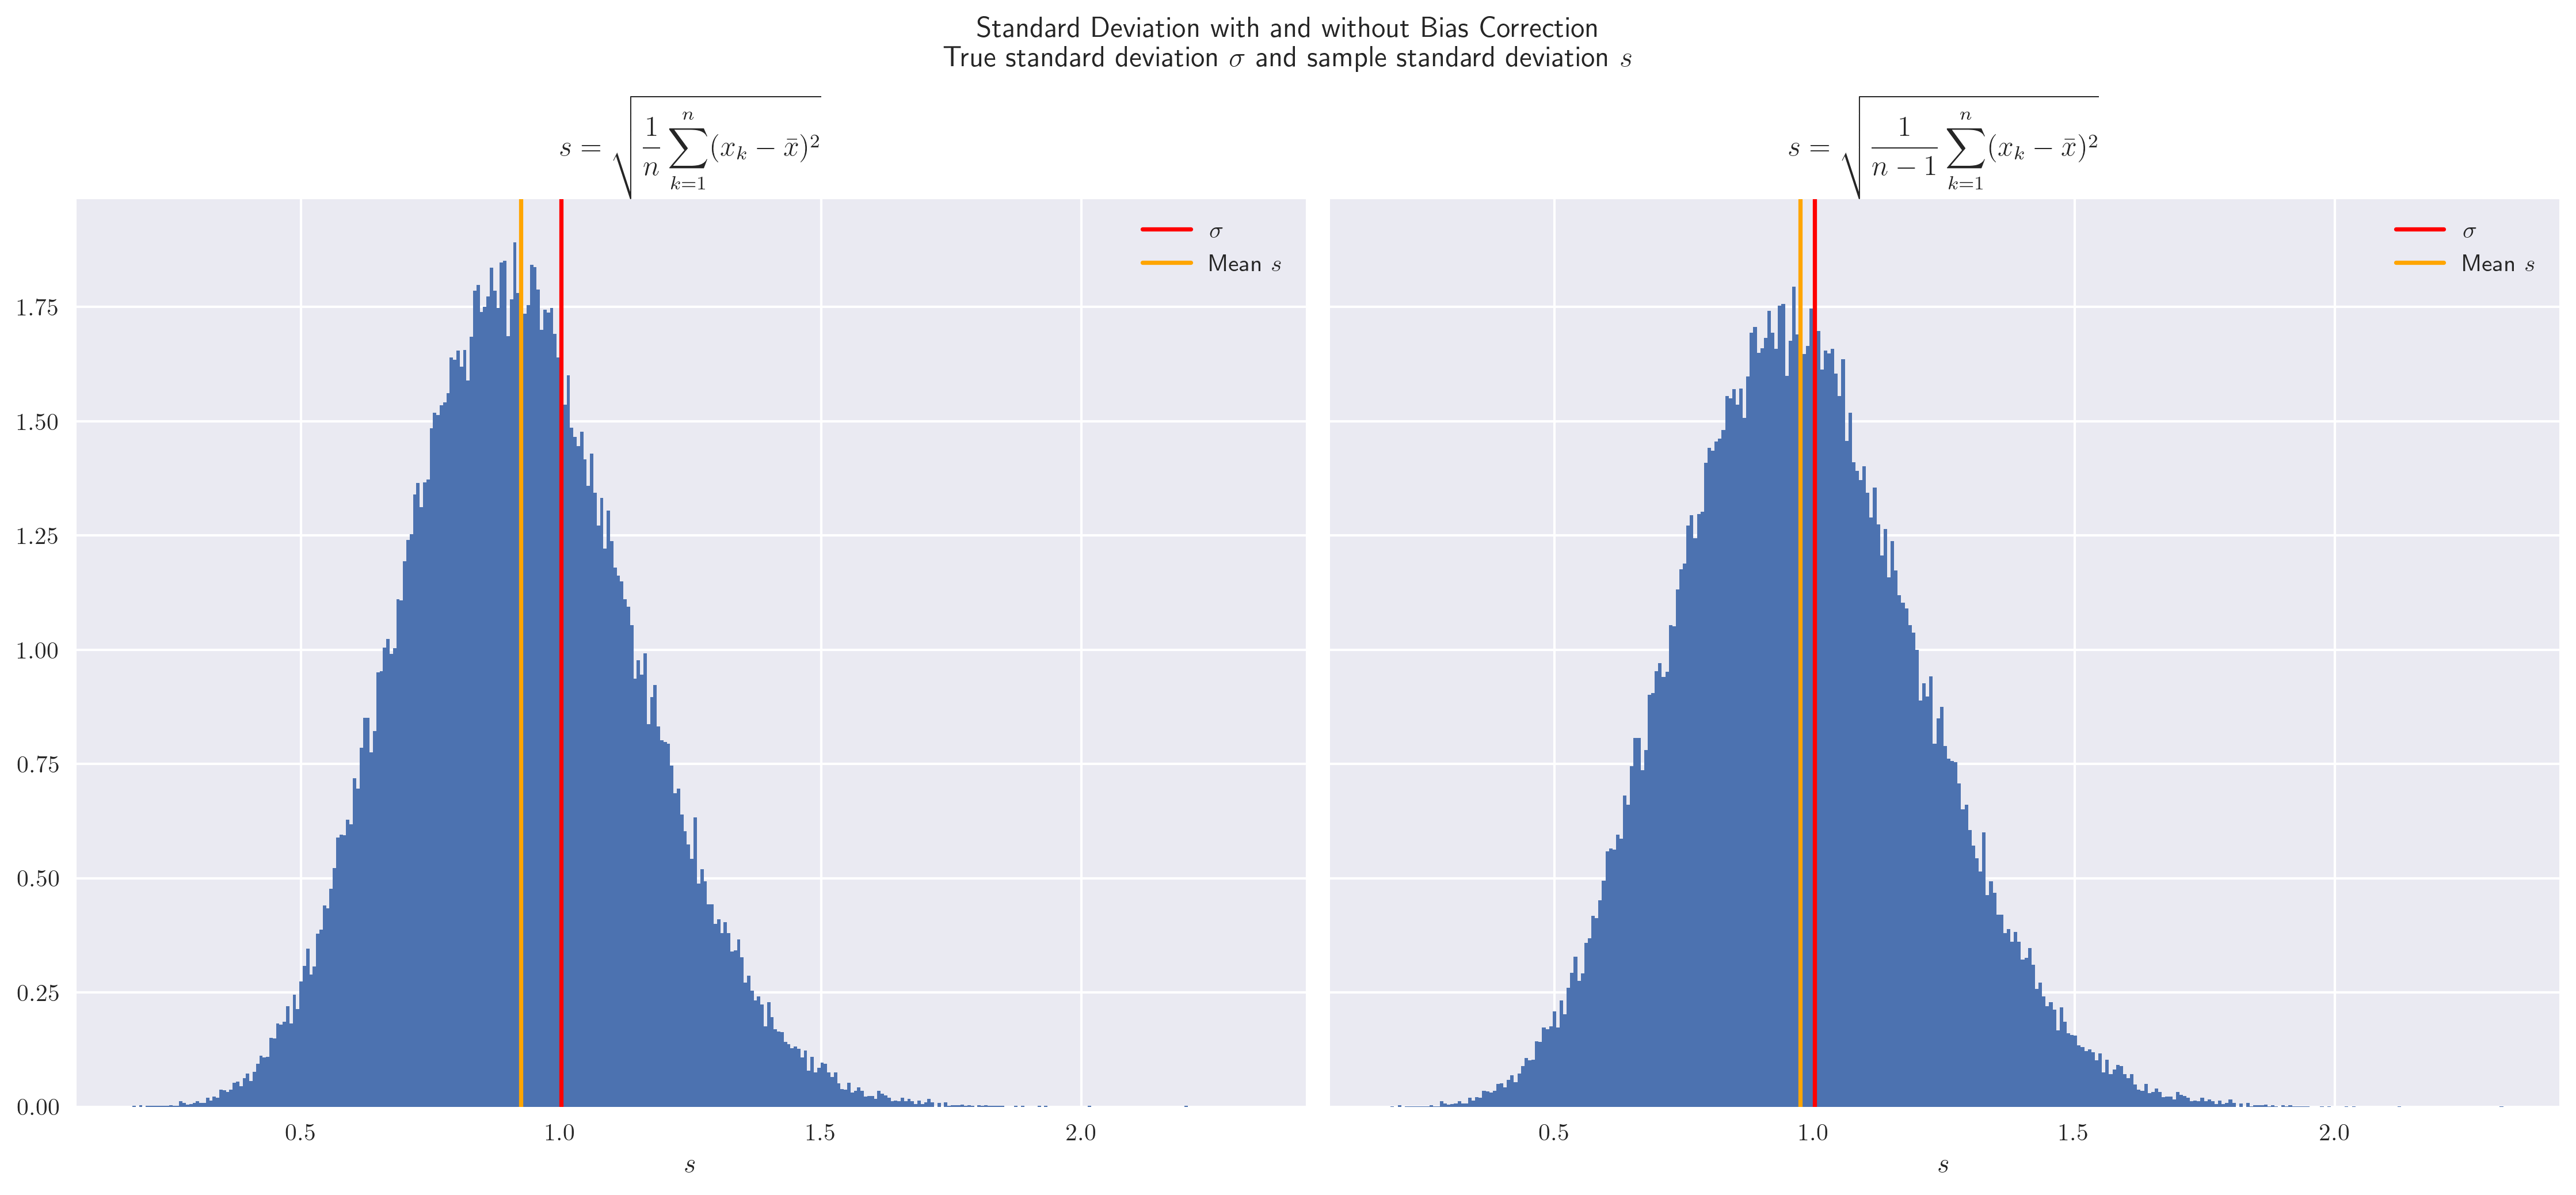

In [149]:
# Import modules
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import norm

# Use LaTeX and increase resolution
plt.rcParams['text.usetex'],  plt.rcParams['figure.dpi'] = True, 300

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Set random seed
np.random.seed(0)

# Define number of trials
trials = 100_000

# Generate normal rvs with mean 0 and variance 1
Z = norm.rvs(loc = 0, scale = 1, size = (10, trials))

# Calculate the sd without bias correction
sd0 = np.apply_along_axis(np.std, 0, Z, ddof = 0)

# Calculate the sd with bias correction
sd1 = np.apply_along_axis(np.std, 0, Z, ddof = 1)

# Define number of bins
num_bins = int(np.sqrt(trials))

# Set up subplots
fig, ax = plt.subplots(1, 2, sharex = True, sharey = True, 
                       figsize = (15, 7))

ax[0].hist(sd0, bins = num_bins, density = True)
ax[0].axvline(x = 1, color = 'red', label = r'$\sigma$')
ax[0].axvline(x = np.mean(sd0), color = 'orange', label = r'Mean $s$')

ax[0].legend()
ax[0].title.set_text(r'$s = \displaystyle\sqrt{\frac{1}{n}\sum_{k = 1}^n (x_k - \bar{x})^2}$')
ax[0].set_xlabel(r'$s$')

ax[1].hist(sd1, bins = num_bins, density = True)
ax[1].axvline(x = 1, color = 'red', label = r'$\sigma$')
ax[1].axvline(x = np.mean(sd1), color = 'orange', label = r'Mean $s$')

ax[1].legend()
ax[1].title.set_text(r'$s = \displaystyle\sqrt{\frac{1}{n - 1}\sum_{k = 1}^n (x_k - \bar{x})^2}$')
ax[1].set_xlabel(r'$s$')

# Give entire figure title
fig.suptitle(r'Standard Deviation with and without Bias Correction' 
             + '\n' + r'True standard deviation $\sigma$ and sample standard deviation $s$')

# Add padding
fig.tight_layout(pad = 1)

# Save the figure
plt.savefig(path + r'ex3-9.png')

plt.show()

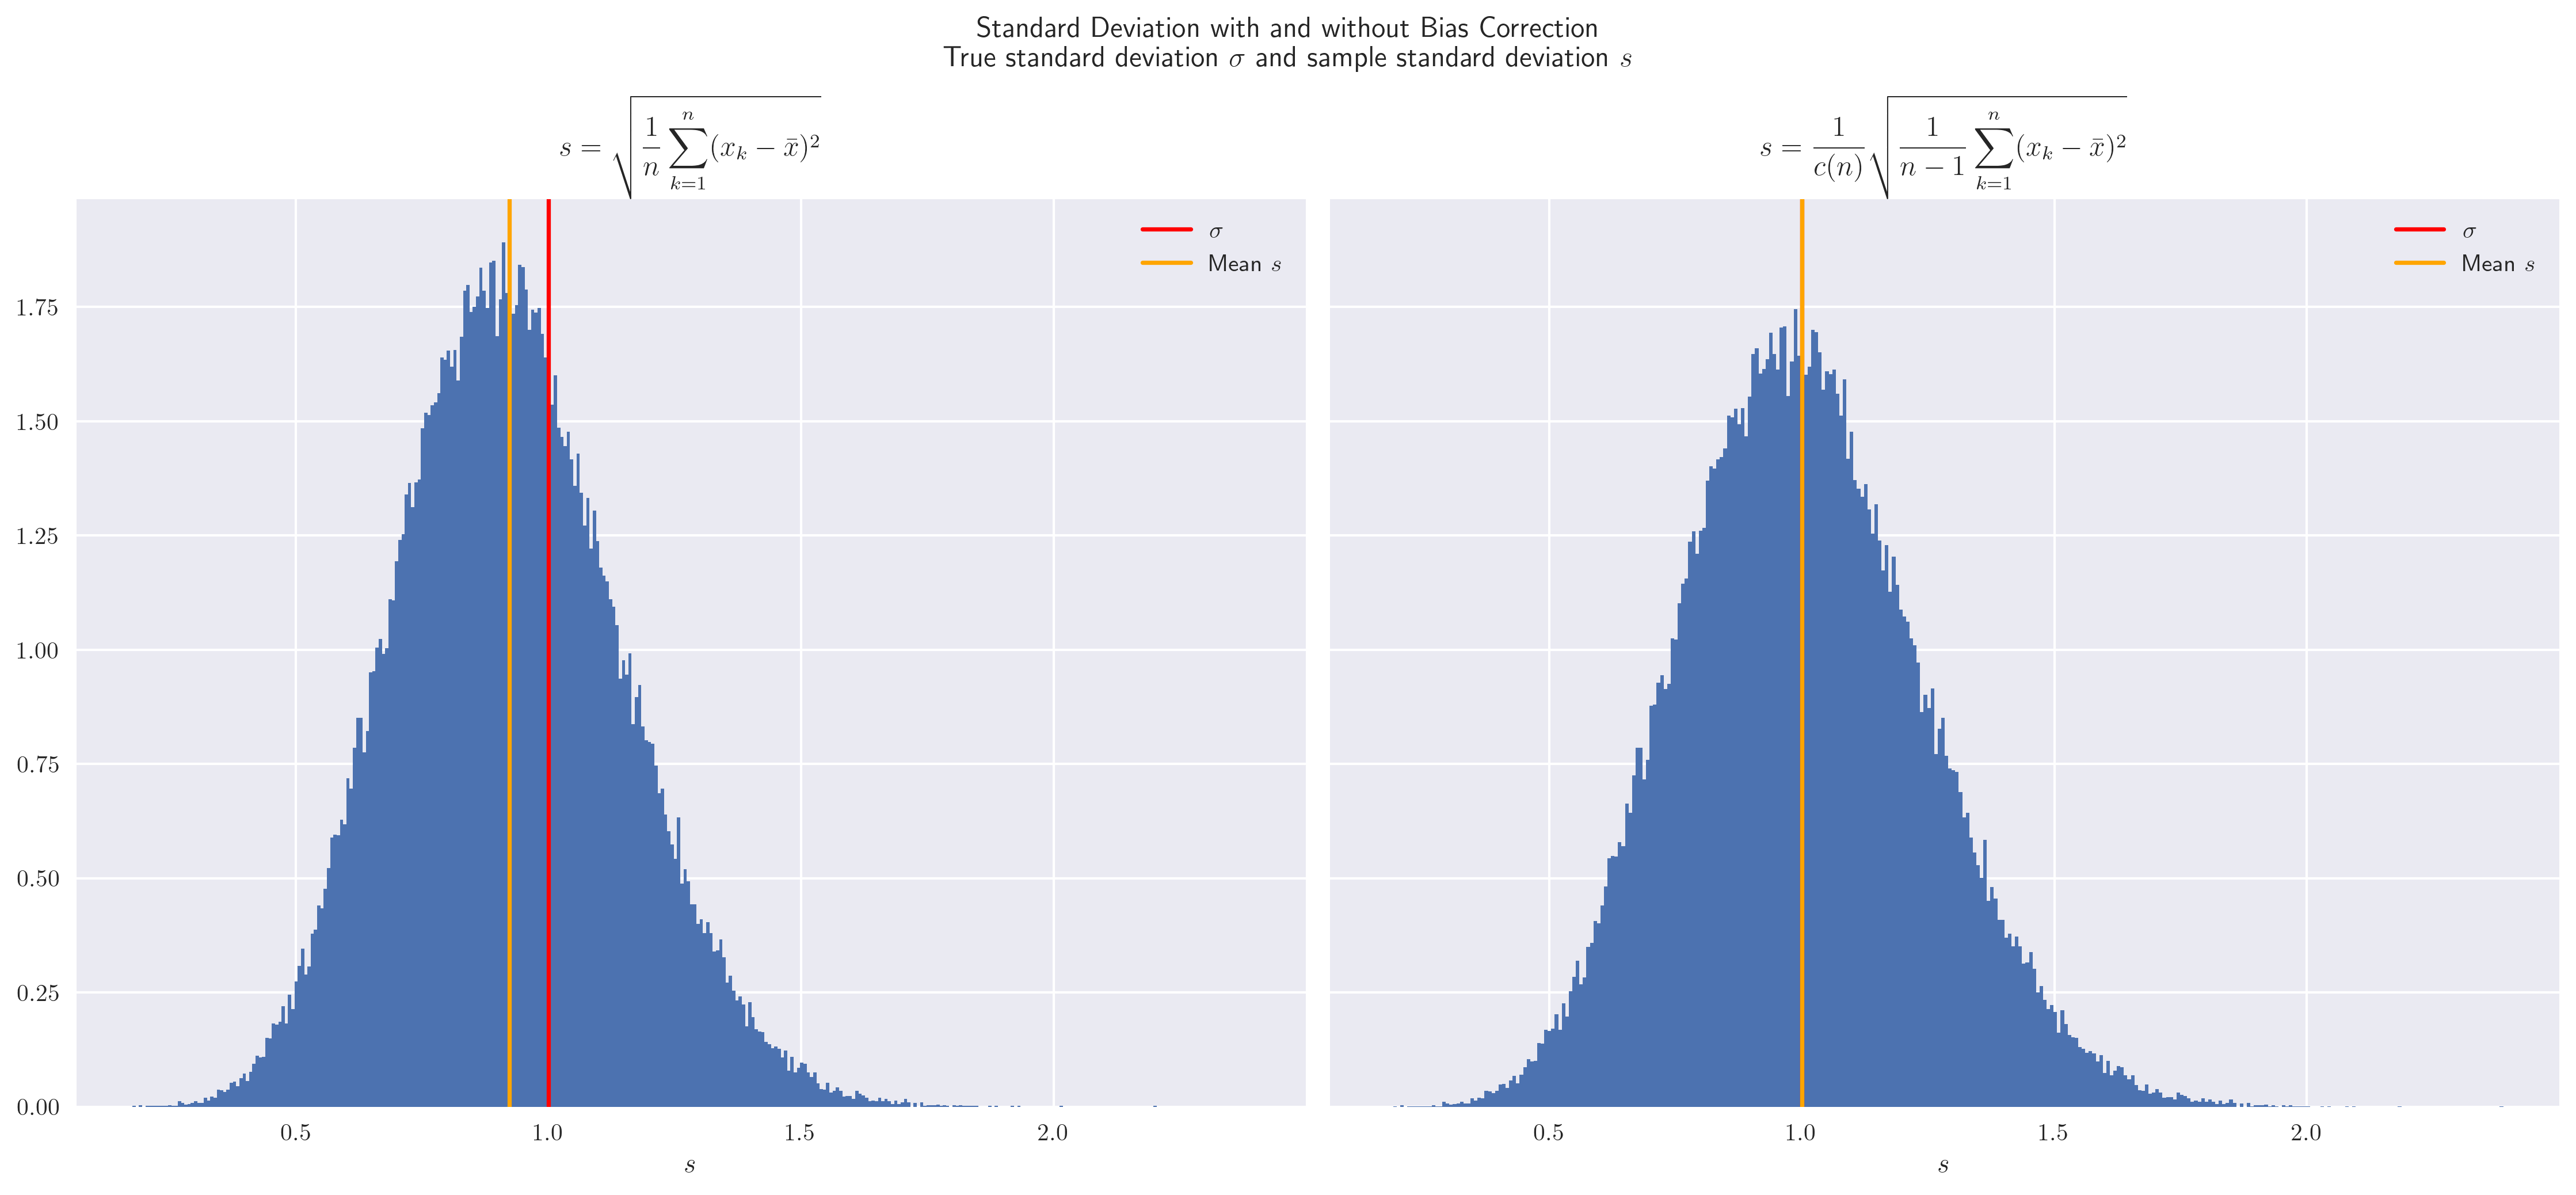

In [20]:
# Import modules
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.special import gamma

# Use LaTeX
plt.rcParams['text.usetex'] = True

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Set random seed
np.random.seed(0)

# Define number of trials
trials = 100_000

# Define number of bins
num_bins = int(np.sqrt(trials))

# Generate normal rvs with mean 0 and variance 1
Z = norm.rvs(loc = 0, scale = 1, size = (10, trials))

# Calculate the sd without bias correction
sd0 = np.apply_along_axis(np.std, 0, Z, ddof = 0)

# Get correct bias correction for normal distribution
# See https://en.wikipedia.org/wiki/Unbiased_estimation_of_standard_deviation
c = lambda n: np.sqrt(2/(n - 1)) * gamma(n/2)/gamma((n - 1)/2)

# Calculate the sd with correct bias correction
sd1 = 1/c(Z.shape[0]) * np.apply_along_axis(np.std, 0, Z, ddof = 1)

# Set up subplots
fig, ax = plt.subplots(1, 2, sharex = True, sharey = True, 
                       figsize = (15, 7))

ax[0].hist(sd0, bins = num_bins, density = True)
ax[0].axvline(x = 1, color = 'red', label = r'$\sigma$')
ax[0].axvline(x = np.mean(sd0), color = 'orange', label = r'Mean $s$')

ax[0].legend()
ax[0].title.set_text(r'$s = \displaystyle\sqrt{\frac{1}{n}\sum_{k = 1}^n (x_k - \bar{x})^2}$')
ax[0].set_xlabel(r'$s$')

ax[1].hist(sd1, bins = num_bins, density = True)
ax[1].axvline(x = 1, color = 'red', label = r'$\sigma$')
ax[1].axvline(x = np.mean(sd1), color = 'orange', label = r'Mean $s$')

ax[1].legend()
ax[1].title.set_text(r'$s = \displaystyle \frac{1}{c(n)}\sqrt{\frac{1}{n - 1}\sum_{k = 1}^n (x_k - \bar{x})^2}$')
ax[1].set_xlabel(r'$s$')

# Give entire figure title
fig.suptitle(r'Standard Deviation with and without Bias Correction' 
             +'\n' + r'True standard deviation $\sigma$ and sample standard deviation $s$')

# Add padding
fig.tight_layout(pad = 1)

plt.show()

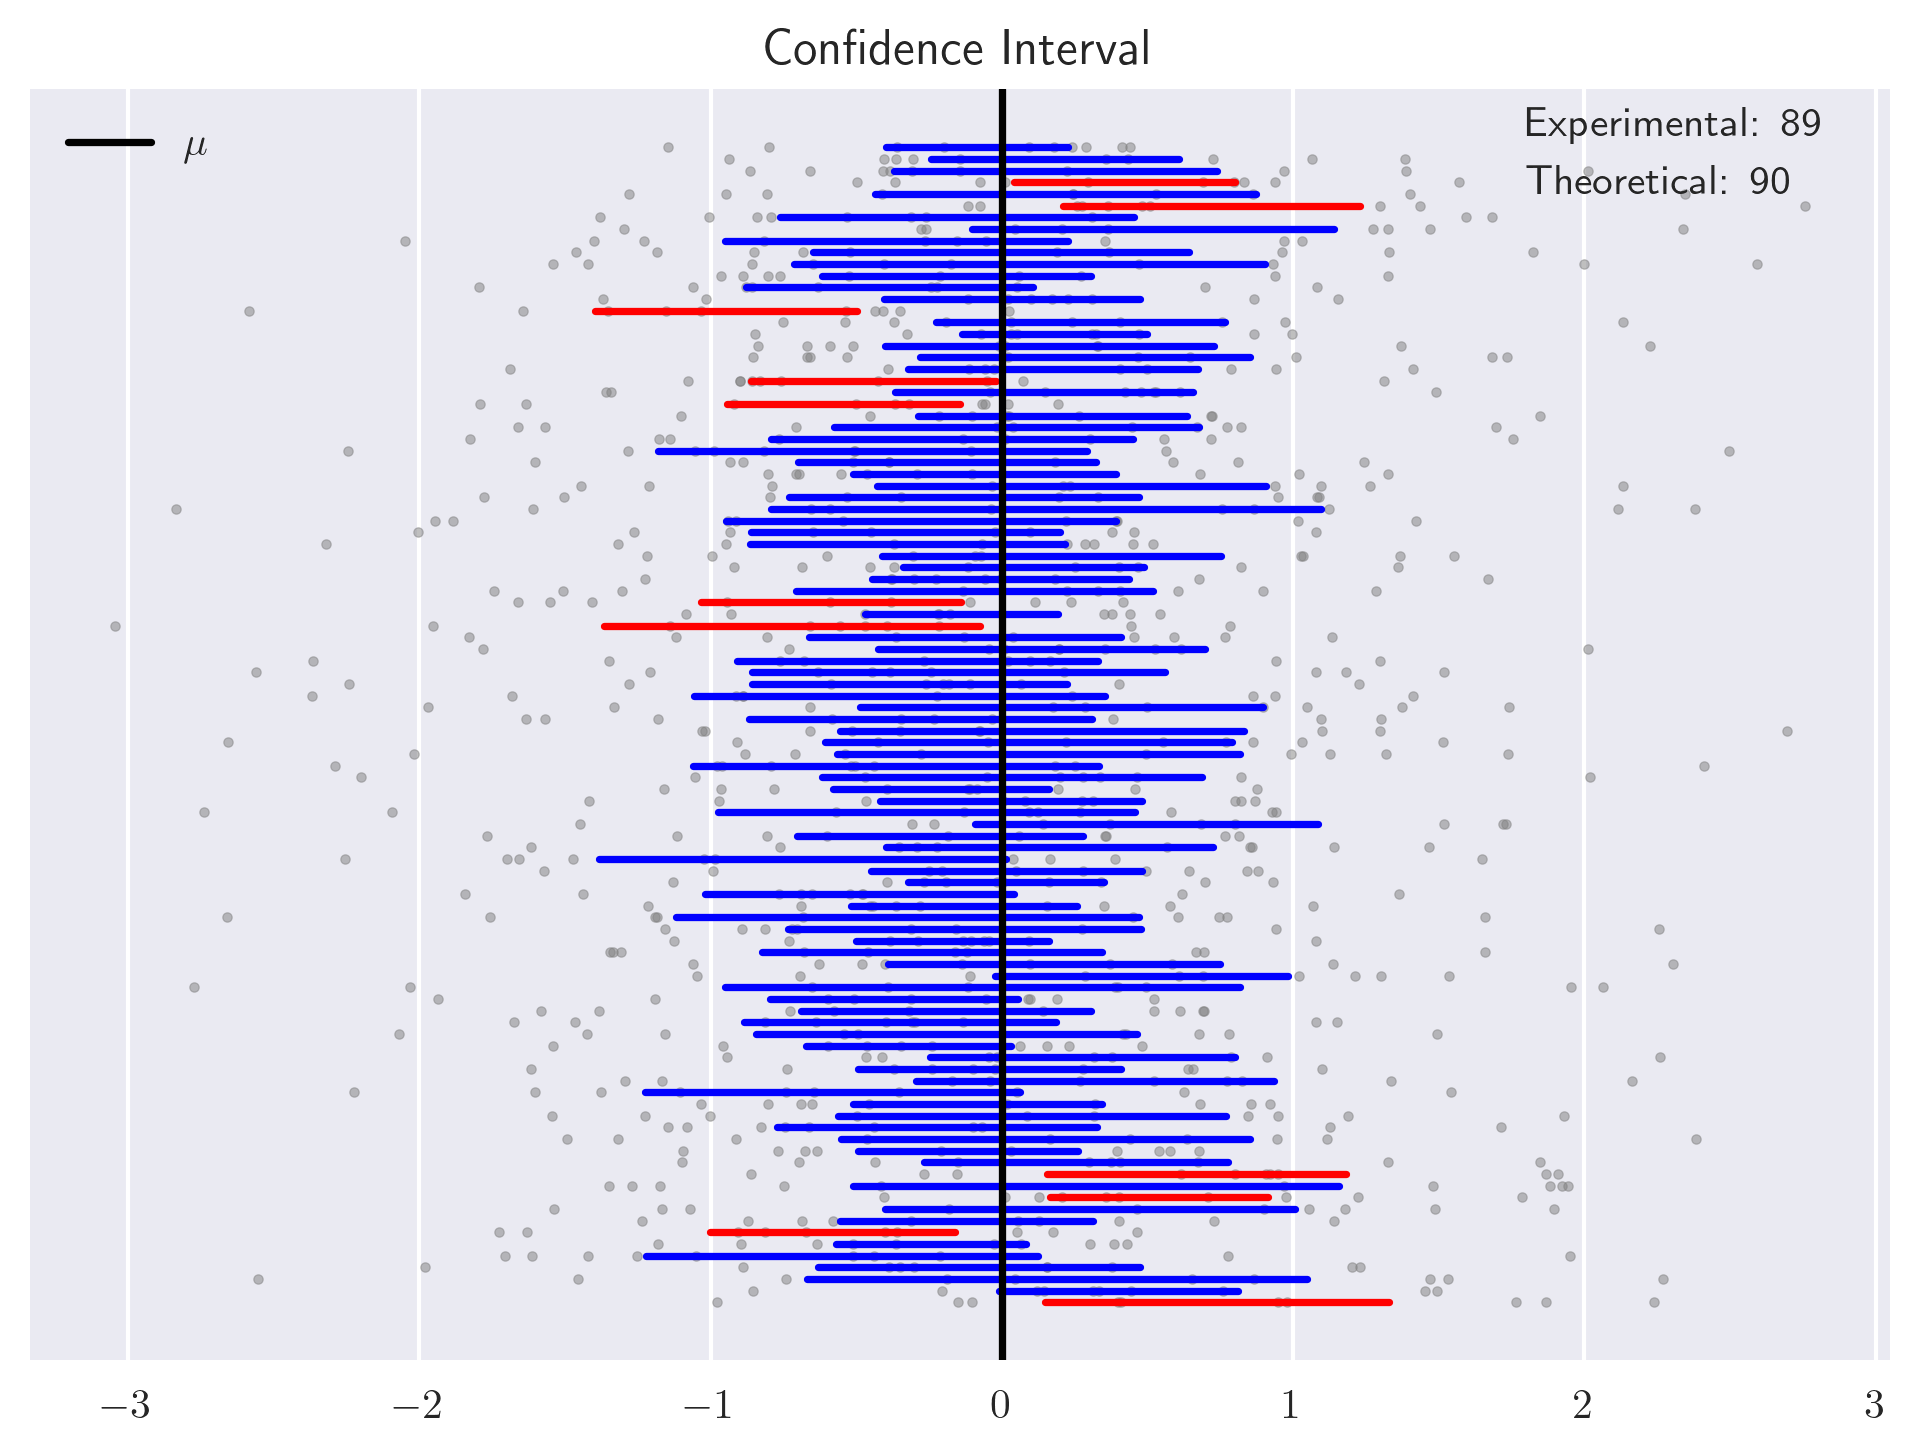

In [151]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t

# Use LaTeX and increase resolution
plt.rcParams['text.usetex'],  plt.rcParams['figure.dpi'] = True, 300

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Set random seed
np.random.seed(0)

# True values are mu = 0 and sigma = 1
mu, sigma = 0, 1

# Samples of size 10
sample_size = 10

# Set significance level
alpha = 0.10

# Calculate lower and upper t-values
t_lower = t.ppf(alpha/2, df = sample_size - 1)
t_upper = t.ppf(1 - alpha/2, df = sample_size - 1)

# How many trials?
trials = 100

# Create counter of times mu is in the interval
num_mu_in_interval = 0

for i in range(trials):

    # Generate sample
    sample = norm.rvs(loc = mu, scale = sigma, size = sample_size)

    # Calculate x_bar and s
    x_bar, s = np.mean(sample), np.std(sample, ddof = 1)

    # Calculate theoretical confidence interval
    lower_bound = x_bar + s/np.sqrt(sample_size) * t_lower
    upper_bound = x_bar + s/np.sqrt(sample_size) * t_upper

    # Check if mu is in the interval
    in_interval = lower_bound < mu < upper_bound

    # Plot sample points
    plt.scatter(sample, sample_size * [i], color = 'gray', s = 5, 
                alpha = 0.5)

    # Define color depending on if interval contains mu
    color = 'blue' if in_interval else 'red'
    
    # Plot confidence interval
    plt.plot([lower_bound, upper_bound], [i, i], color = color)

    # Add to count
    num_mu_in_interval += int(in_interval)

# Add a vertical line where mu is
plt.axvline(x = mu, color = 'black', label = r'$\mu$')

# Don't need the vertical integer numbering
plt.yticks([])

# Add a title
plt.title('Confidence Interval')

# Add annotation for results
plt.annotate(f'Experimental: {100 * num_mu_in_interval/trials:0.0f}%', 
             xy = (1.8, trials))
plt.annotate(f'Theoretical: {100 * (1 - alpha):0.0f}%', 
             xy = (1.8, trials - 5))

# Add legend
plt.legend()

# Save the figure
plt.savefig(path + r'ex3-10.png')

plt.show()   